<a href="https://colab.research.google.com/github/malcolmlett/training-instrumentation-toolkit/blob/main/doc/blog-202503/better-visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Better Visualisations
This notebook creates some of the visualizations used in the introductory article in a series that looks at improving model introspection and visualization. The main focus here is on visualizing the weights and gradients.

**Preliminaries**

This notebook follows a "guide" style, but it assumes that you have some familiarity with the `training-instrumentation-toolkit`. Please see the notebooks in the following github location for an introduction:
* https://github.com/malcolmlett/training-instrumentation-toolkit/blob/main/doc/index.md

The results below were achieved while running the notebook in Google Colab with a T4 GPU.

**Blog Post**

This notebook was prepared for the following May 2025 blog post:
* https://ai.gopubby.com/better-ways-to-monitor-nns-while-training-7c246867ca4f


In [ ]:
# Load TensorBoard notebook extension
%load_ext tensorboard

# Install Training Instrumentation Toolkit
# (locked to specific git revision so this notebook always works)
import os
import sys
if not os.path.isdir('training-instrumentation-toolkit'):
  !git clone https://github.com/malcolmlett/training-instrumentation-toolkit.git
  !cd training-instrumentation-toolkit && git checkout feda2e7
sys.path.append('training-instrumentation-toolkit')

# Imports
import sys
import train_instrumentation as tinstr
import train_explainer as texpl
import tensorflow as tf
from tensorflow.keras import layers
import tqdm
import datetime
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sklearn
import scipy

# Prefer consistent behaviour
tf.config.experimental.enable_op_determinism()

Cloning into 'training-instrumentation-toolkit'...
remote: Enumerating objects: 1586, done.
remote: Counting objects: 100% (146/146), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 1586 (delta 97), reused 95 (delta 51), pack-reused 1440 (from 2)
Receiving objects: 100% (1586/1586), 164.52 MiB | 12.30 MiB/s, done.
Resolving deltas: 100% (954/954), done.
Note: switching to 'feda2e7'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at feda2e7 Latest state of blog notebooks prior to fixing bugs w

In [ ]:
# Versions and hardware used when this notebook was last succesfully run
print(f"Python:     {sys.version}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras:      {tf.keras.__version__}")
print(f"Numpy:      {np.__version__}")
print(f"Devices:    {tf.config.list_physical_devices()}")

Python:     3.11.12 (main, Apr  9 2025, 08:55:54) [GCC 11.4.0]
TensorFlow: 2.18.0
Keras:      3.8.0
Numpy:      2.0.2
Devices:    [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Re-usable functions
First, let's define some functions that are going to be reused throughout.

In [ ]:
# Runs through the dataset once and calculates the average gradient for each trainable variable.
@tf.function
def _measure_gradients_loop(model, dataset, optimizer, grad_sums):
  n = 0.0
  for x_batch_train, y_batch_train in dataset:
    n += 1
    with tf.GradientTape() as tape:
      result = model(x_batch_train, training=True)
      loss = model.compute_loss(x_batch_train, y_batch_train, result, training=True)
      loss = optimizer.scale_loss(loss)
    grads = tape.gradient(loss, model.trainable_variables)
    for i, grad in enumerate(grads):
      grad_sums[i].assign_add(grad)
  return n

def measure_gradients(model, dataset):
  grad_sums = [tf.Variable(tf.zeros_like(v)) for v in model.trainable_variables]
  optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
  n = _measure_gradients_loop(model, dataset, optimizer, grad_sums)

  return [grad_sum / n for grad_sum in grad_sums]

def short_path(variable_path):
  """converts from 'sequential_3/dense1/kernel' to 'sequential_3/dense1/kernel'"""
  return "/".join(variable_path.split("/")[-2:])

def plot_variable_histograms(model):
  num_vars = len(model.trainable_variables)
  layer_indices = tinstr.layer_indices_by_trainable_variable(model)
  var_display_names = [f"layer {l_idx}:\n{short_path(v.path)}" for v, l_idx in zip(model.trainable_variables, layer_indices)]

  plot_cols = 4
  plot_rows = np.ceil(num_vars / plot_cols).astype(np.int32)
  plt.figure(figsize=(10, 2*plot_rows), layout='constrained')

  for v_idx, v in enumerate(model.trainable_variables):
    plt.subplot(plot_rows, plot_cols, v_idx+1)
    plt.title(var_display_names[v_idx])
    plt.hist(v.numpy().flatten(), bins=50)
    plt.xlabel("value")
    plt.ylabel("histogram count")
  plt.show()

def plot_gradient_histograms(model, dataset):
  """Plots a probability-density-function (PDF) estimated from the latest value_stats of whichever callback is provided"""
  num_vars = len(model.trainable_variables)
  layer_indices = tinstr.layer_indices_by_trainable_variable(model)
  var_display_names = [f"layer {l_idx}:\n{short_path(v.path)}" for v, l_idx in zip(model.trainable_variables, layer_indices)]

  # sample gradients in current state
  gradients = measure_gradients(model, dataset)

  plot_cols = 4
  plot_rows = np.ceil(num_vars / plot_cols).astype(np.int32)
  plt.figure(figsize=(10, 2*plot_rows), layout='constrained')

  p_idx = 1
  for v_idx, grad in enumerate(gradients):
    plt.subplot(plot_rows, plot_cols, v_idx+1)
    plt.title(var_display_names[v_idx])
    plt.hist(grad.numpy().flatten(), bins=50)
    plt.xlabel("value")
    plt.ylabel("histogram count")
  plt.show()

## Statistical Measures
There are a few different ways that you can measure tensors. Here's a summary of some of them, along with their equations:

**L2-norm**:
$$\text{norm(X)} = \sqrt {\sum x_i^2}$$

**Size-normalized L2-norm:**
$$
\begin{align*}
\text{size-normalized-norm(X)}
&= \frac{1}{\sqrt{\text{size}(X)}} \sqrt{\sum x_i^2} \\
&= \sqrt{ \frac{1}{\text{size}(X)} \sum x_i^2 } \\
&= \sqrt{ \mathbb{E}[X^2] } = \text{root-mean-square}(X)
\end{align*}
$$

**Mean:**
$$\bar{X} = \mathbb{E}[X] = \frac{1}{\text{size}(X)} \sum x_i$$

**Stddev:**
$$
\begin{align*}
\sigma(X) = \text{Var}(X)
&= \sqrt {\frac{1}{\text{size}(X)} \sum (x_i - \bar{X})^2 } \\
&= \sqrt{ \mathbb{E}[X^2] - (\mathbb{E}[X])^2 }
\end{align*}
$$

Notice that some of these measure similar things under common conditions when training neural networks:
* The mean of the gradients is usually very close to zero, and so the stddev and root-mean-square measure the same thing:
$$
\begin{align*}
\text{Var}(X)
&\approx \sqrt{ \mathbb{E}[X^2] - 0 }\\
&= \sqrt{\mathbb{E}[X^2]} = \text{root-mean-square}(X)
\end{align*}
$$

* Whereas the mean magnitude of gradients approximates an L1-equivalent of stddev:
$$
\begin{align*}
\text{Var}_1(X)
&= \mathbb{E}[\text{abs}(X)] - \text{abs}(\mathbb{E}[X]) \\
&\approx \mathbb{E}[\text{abs}(X)] - 0 \\
&= \mathbb{E}[\text{abs}(X)] = \text{mean-magnitude}(X)
\end{align*}
$$

Finally, if you only have percentile data and you're only interested in the general scale of values without being concerned about exact accurancy, you can use the following as approximate replacements:
* 50th percentile of raw values $\approx$ mean
* $\frac{1}{2}$ (75th percentile - 25th percentiles) $\approx$ stddev
* 50th percentile of magnitudes $\approx$ stddev (for gradients)
* geometric mean of percentiles of magnitudes = $\text{exp}(\mathbb{E}[\text{log}(P)])$ $\approx$ stddev (for gradients)


## Binary Classification Problem
We'll start with a simple problem, and explore some different ways to visualise the model parameters and gradients.

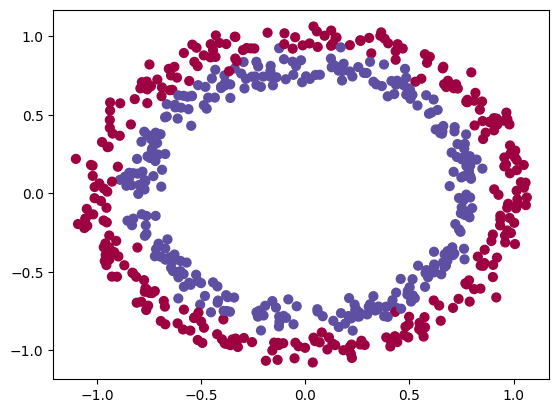

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1a (Dense)                 │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1b (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2a (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2b (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchNorm3 (BatchNormalization) │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense4 (Dense)                  │ (None, 5)              │           505 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense5 (Dense)                  │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,611 (162.54 KB)

 Trainable params: 41,411 (161.76 KB)

 Non-trainable params: 200 (800.00 B)

In [ ]:
# Using a slightly more elaborate model than needed for such a simple task in order
# to illustrate how dropout and normalization layers appear in visualisations
def binary_classification_model():
  model = tf.keras.Sequential([
    layers.Input(shape=(2,), name='input'),
    layers.Dense(100, activation='relu', kernel_initializer='he_normal', name='dense1a'),
    layers.Dense(100, activation='relu', kernel_initializer='he_normal', name='dense1b'),
    layers.Dropout(rate=0.2, name='dropout1'),
    layers.Dense(100, activation='relu', kernel_initializer='he_normal', name='dense2a'),
    layers.Dense(100, activation='relu', kernel_initializer='he_normal', name='dense2b'),
    layers.Dropout(rate=0.2, name='dropout2'),
    layers.Dense(100, activation='relu', kernel_initializer='he_normal', name='dense3'),
    layers.BatchNormalization(name='batchNorm3'),
    layers.Dense(5, activation='relu', kernel_initializer='he_normal', name='dense4'),
    layers.Dense(1, activation='sigmoid', kernel_initializer='he_normal', name='dense5')
  ])
  return model

def binary_classification_dataset():
  X, Y = sklearn.datasets.make_circles(n_samples=3000, noise=.05)
  return X, Y

train_X, train_Y = binary_classification_dataset()
plt.scatter(train_X[0:600, 0], train_X[0:600, 1], c=train_Y[0:600], s=40, cmap=plt.cm.Spectral);
plt.show()

binary_classification_model().summary()

## TensorBoard
Let's use TensorBoard first.
We'll use it to produce those very beautiful stacked histograms.

It doesn't take too much effort to get histograms over the model parameters.
And it uses something called _Reservior Sampling_, so that it's quite efficient with collecting the histogram data.

However, it doesn't provide anything out of the box to collect gradients - which are far more useful. So we'd still need all the effort of a custom training loop.

Also, TensorBoard seems to be quite finickity. It's out-of-box callback didn't correctly collect data for the layers so I had to create my own callback here.

In [ ]:
# Clear any logs from previous runs
!rm -rf ./logs/

class CustomSummaryLogger(tf.keras.callbacks.Callback):
    def __init__(self, logdir):
        super().__init__()
        self.summary_writer = tf.summary.create_file_writer(logdir + '/custom')

    def on_epoch_end(self, epoch, logs=None):
      with self.summary_writer.as_default():
        tf.summary.scalar('loss', logs['loss'], step=epoch)
        tf.summary.scalar('accuracy', logs['accuracy'], step=epoch)

        for v in self.model.trainable_variables:
          tf.summary.histogram(v.path, v, step=epoch)
      pass

tf.keras.utils.set_random_seed(1)

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
print(f"log_dir: {log_dir}")
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

model = binary_classification_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
train_X, train_Y = binary_classification_dataset()
print(f"dataset: X={train_X.shape}, Y={train_Y.shape}")
history = model.fit(x=train_X, y=train_Y, batch_size=32, epochs=50, validation_split=0.2, verbose=0, callbacks=[tinstr.LessVerboseProgressLogger(), tensorboard_cb, CustomSummaryLogger(log_dir)])

log_dir: logs/fit/20250416-015745
dataset: X=(3000, 2), Y=(3000,)
Epoch     5 - 1.57s/epoch: accuracy: 0.8325  loss: 0.3699  val_accuracy: 0.9167  val_loss: 0.2223  
Epoch    10 - 1.02s/epoch: accuracy: 0.9083  loss: 0.2199  val_accuracy: 0.5300  val_loss: 1.4823  
Epoch    15 - 997.23ms/epoch: accuracy: 0.9287  loss: 0.1719  val_accuracy: 0.5817  val_loss: 1.5095  
Epoch    20 - 1.08s/epoch: accuracy: 0.9375  loss: 0.1516  val_accuracy: 0.5750  val_loss: 1.3403  
Epoch    25 - 918.80ms/epoch: accuracy: 0.9479  loss: 0.1375  val_accuracy: 0.6367  val_loss: 1.0799  
Epoch    30 - 1.19s/epoch: accuracy: 0.9521  loss: 0.1209  val_accuracy: 0.7683  val_loss: 0.6978  
Epoch    35 - 1.10s/epoch: accuracy: 0.9575  loss: 0.1142  val_accuracy: 0.8167  val_loss: 0.5471  
Epoch    40 - 1.13s/epoch: accuracy: 0.9558  loss: 0.1170  val_accuracy: 0.8850  val_loss: 0.3129  
Epoch    45 - 923.94ms/epoch: accuracy: 0.9642  loss: 0.1002  val_accuracy: 0.9167  val_loss: 0.1937  
Epoch    50 - 996.23ms/ep

In [ ]:
# notebook has to be executed to see output
%tensorboard --logdir logs/fit

# Custom Training Loop
This illustrates the simplest form of a custom training loop that collects the following while also providing some of the basic support that you get out of the box from the standard model.fit():
* Loss and metrics per-step instead of per-epoch
* Variables at each step (ie: weights, biases, etc.)
* Gradients at each step (of weights, biases, etc.)
* Layer outputs
* Gradients of layer outputs

  0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 2))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(24, 2))
  warnings.warn(msg)
100%|██████████| 5/5 [01:04<00:00, 12.96s/it]


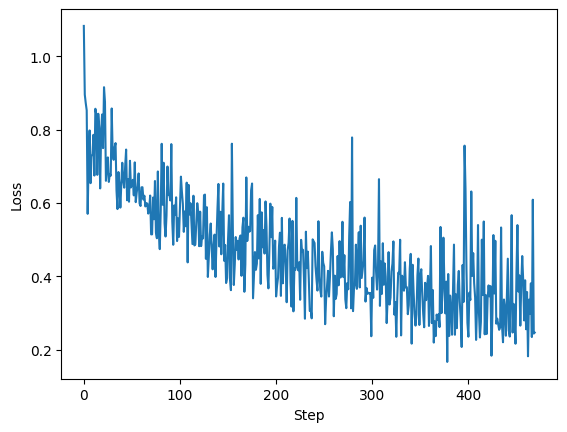

In [ ]:
import tensorflow as tf
import tqdm

def custom_fit(model, train_dataset, epochs, optimizer):
  # unpack model during training so we get access to individual layer outputs
  monitoring_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[model.outputs] + [layer.output for layer in model.layers])

  loss_history = []
  metrics_history = []
  variables_history = []
  gradients_history = []
  layer_outputs_history = []
  layer_gradients_history = []

  for epoch in tqdm.tqdm(range(epochs)):
    for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):
      with tf.GradientTape() as tape:
        monitoring_outputs = monitoring_model(x_batch_train, training=True)
        y_pred = monitoring_outputs[0][0]
        layer_outputs = monitoring_outputs[1:]
        loss = model.compute_loss(x_batch_train, y_batch_train, y_pred, training=True)
        loss = optimizer.scale_loss(loss)
      all_grads = tape.gradient(loss, model.trainable_weights + layer_outputs)
      trainable_grads = all_grads[:len(model.trainable_variables)]
      output_grads = all_grads[len(model.trainable_variables):]
      optimizer.apply_gradients(zip(trainable_grads, model.trainable_weights))
      metrics = model.compute_metrics(x_batch_train, y_batch_train, y_pred)

      loss_history.append(loss)
      metrics_history.append(metrics)
      variables_history.append([tf.identity(v) for v in model.trainable_variables])
      gradients_history.append(trainable_grads)
      layer_outputs_history.append(layer_outputs)
      layer_gradients_history.append(output_grads)

  return loss_history, metrics_history, variables_history, gradients_history, layer_outputs_history, layer_gradients_history

# try it out
tf.keras.utils.set_random_seed(1)
model = binary_classification_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])
train_X, train_Y = binary_classification_dataset()
train_dataset = tf.data.Dataset.from_tensor_slices((train_X, train_Y)).batch(32)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
hists = custom_fit(model, train_dataset, 5, optimizer)

# plot loss curve
plt.plot(hists[0])
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## Using Toolkit for capturing data

In [ ]:
tf.keras.utils.set_random_seed(1)

# Run a full training sequence and collect default information for each of the four main callbacks.
# We'll also use the extended `HistoryStats` callback for loss and metric history.
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = binary_classification_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
train_X, train_Y = binary_classification_dataset()
print(f"dataset: X={train_X.shape}, Y={train_Y.shape}")
history = tinstr.fit(model, x=train_X, y=train_Y, batch_size=32, epochs=50, validation_split=0.2, verbose=0,
                     callbacks=[tinstr.LessVerboseProgressLogger(), variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

# PS: any tf.function retracing warnings can be safely ignored.

dataset: X=(3000, 2), Y=(3000,)


Epoch     5 - 5.96s/epoch: accuracy: 0.8325  loss: 0.3699  val_accuracy: 0.9167  val_loss: 0.2223  
Epoch    10 - 2.09s/epoch: accuracy: 0.9083  loss: 0.2199  val_accuracy: 0.5300  val_loss: 1.4823  
Epoch    15 - 2.36s/epoch: accuracy: 0.9287  loss: 0.1719  val_accuracy: 0.5817  val_loss: 1.5095  
Epoch    20 - 2.32s/epoch: accuracy: 0.9375  loss: 0.1516  val_accuracy: 0.5750  val_loss: 1.3403  
Epoch    25 - 2.71s/epoch: accuracy: 0.9479  loss: 0.1375  val_accuracy: 0.6367  val_loss: 1.0799  
Epoch    30 - 2.18s/epoch: accuracy: 0.9521  loss: 0.1209  val_accuracy: 0.7683  val_loss: 0.6978  
Epoch    35 - 2.54s/epoch: accuracy: 0.9575  loss: 0.1142  val_accuracy: 0.8167  val_loss: 0.5471  
Epoch    40 - 2.43s/epoch: accuracy: 0.9558  loss: 0.1170  val_accuracy: 0.8850  val_loss: 0.3129  
Epoch    45 - 2.30s/epoch: accuracy: 0.9642  loss: 0.1002  val_accuracy: 0.9167  val_loss: 0.1937  
Epoch    50 - 2.18s/epoch: accuracy: 0.9554  loss: 0.1090  val_accuracy: 0.8850  val_loss: 0.2959  


## Basic Plot
Typically someone will use the history data to generate a simple plot like the following, or maybe they'll use a tool like TensorBoard to do it for them:

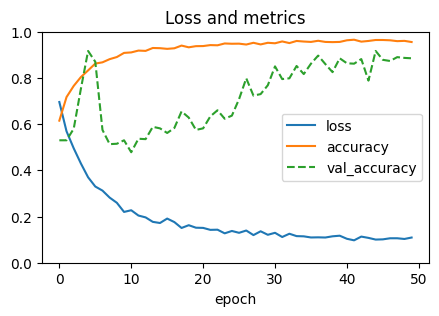

In [ ]:
def simple_history_plot(history_cb):
  plt.figure(figsize=(5,3))
  plt.title("Loss and metrics")

  plt.plot(history_cb.history['loss'], label='loss')
  plt.plot(history_cb.history['accuracy'], label='accuracy')
  #plt.plot(history_cb.history['val_loss'], label='val_loss')  # skipping because too messy
  plt.plot(history_cb.history['val_accuracy'], '--', label='val_accuracy')
  plt.ylim([0.0, 1.0])
  plt.legend()
  plt.xlabel('epoch')
  plt.show()

simple_history_plot(history)

## Overview Plots

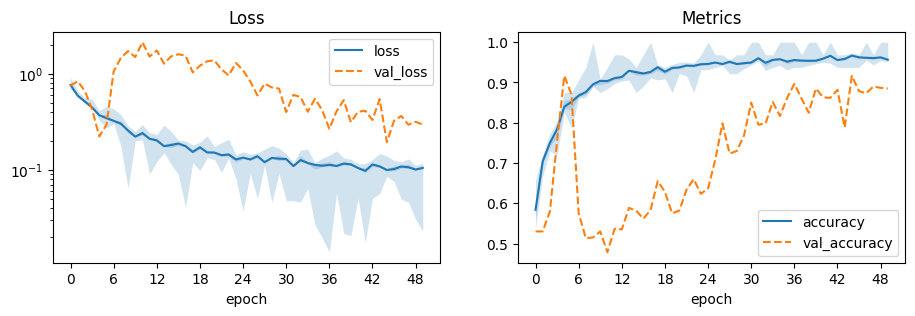

In [ ]:
tinstr.plot_train_history(history)

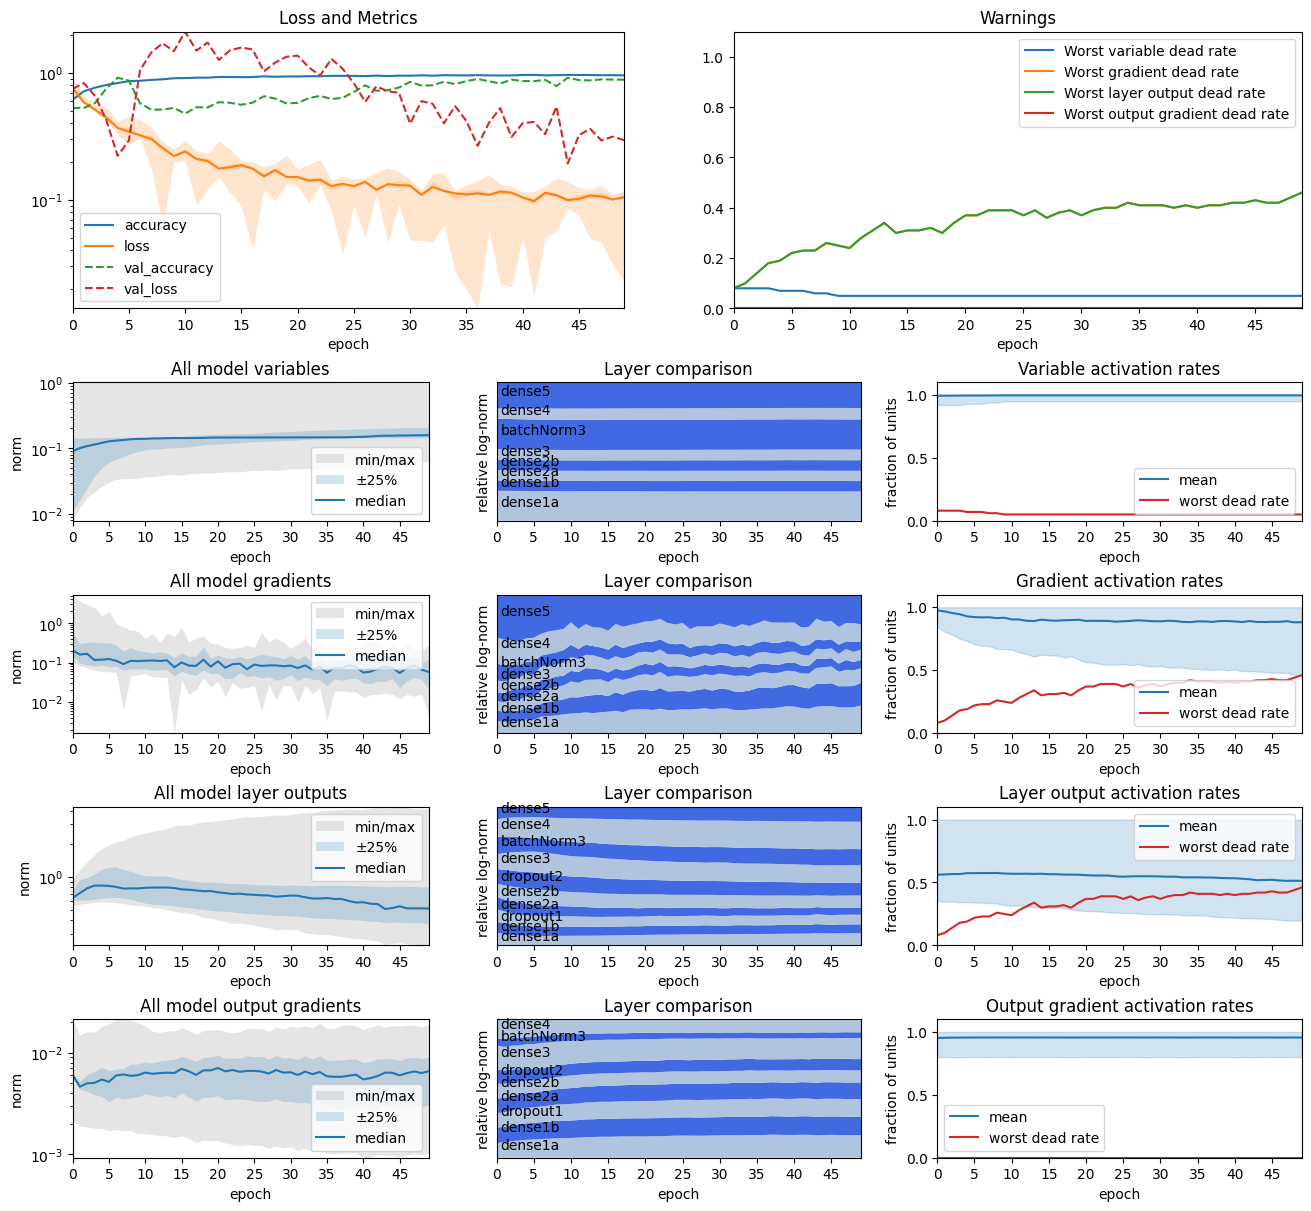

In [ ]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

## Basic Plotting of Weights and Biases
This section looks at various ideas around plotting the values of model parameters (weights and biases), and also of gradients.

To get an idea of the effects of initialization, we can create a dummy model with different initialization schemes and their the weights and biases before training.

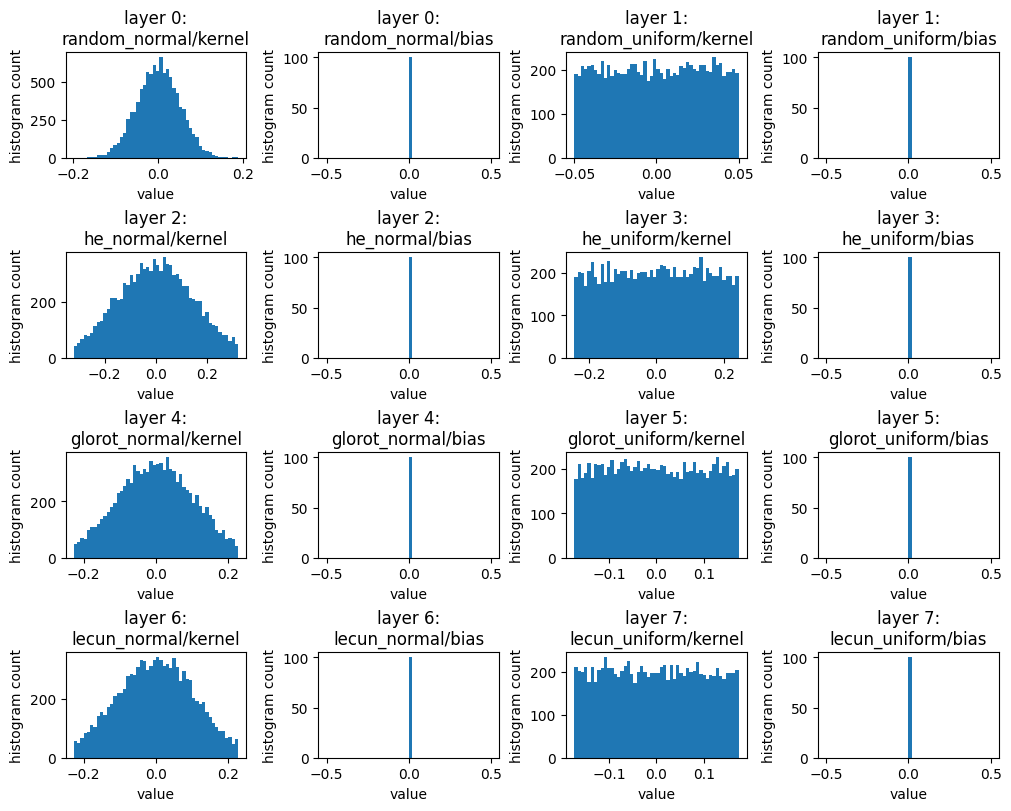

In [ ]:
def mixed_initialization_model():
  model = tf.keras.Sequential([
    layers.Input(shape=(100,)),
    layers.Dense(100, activation='relu', kernel_initializer='random_normal', name='random_normal'),
    layers.Dense(100, activation='relu', kernel_initializer='random_uniform', name='random_uniform'),
    layers.Dense(100, activation='relu', kernel_initializer='he_normal', name='he_normal'),
    layers.Dense(100, activation='relu', kernel_initializer='he_uniform', name='he_uniform'),
    layers.Dense(100, activation='relu', kernel_initializer='glorot_normal', name='glorot_normal'),
    layers.Dense(100, activation='relu', kernel_initializer='glorot_uniform', name='glorot_uniform'),
    layers.Dense(100, activation='relu', kernel_initializer='lecun_normal', name='lecun_normal'),
    layers.Dense(100, activation='relu', kernel_initializer='lecun_uniform', name='lecun_uniform')
  ])
  return model

plot_variable_histograms(mixed_initialization_model())

Compare that to an initialized version of the model we're actually using:

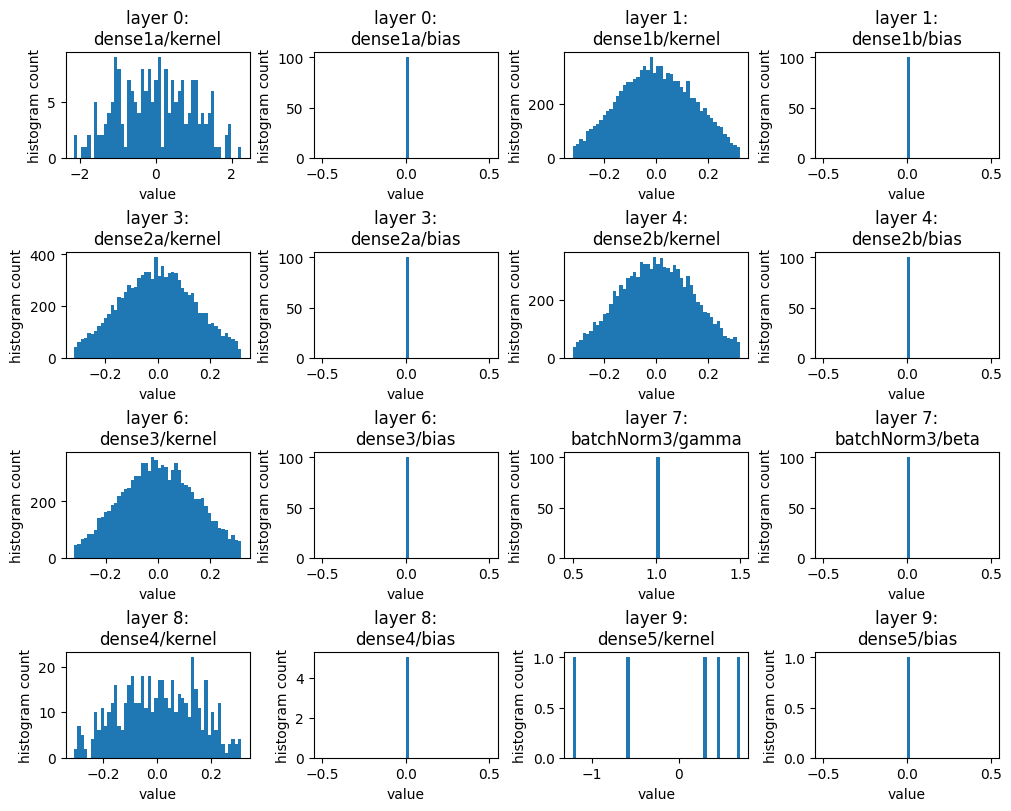

In [ ]:
plot_variable_histograms(binary_classification_model())

And then for our trained model...

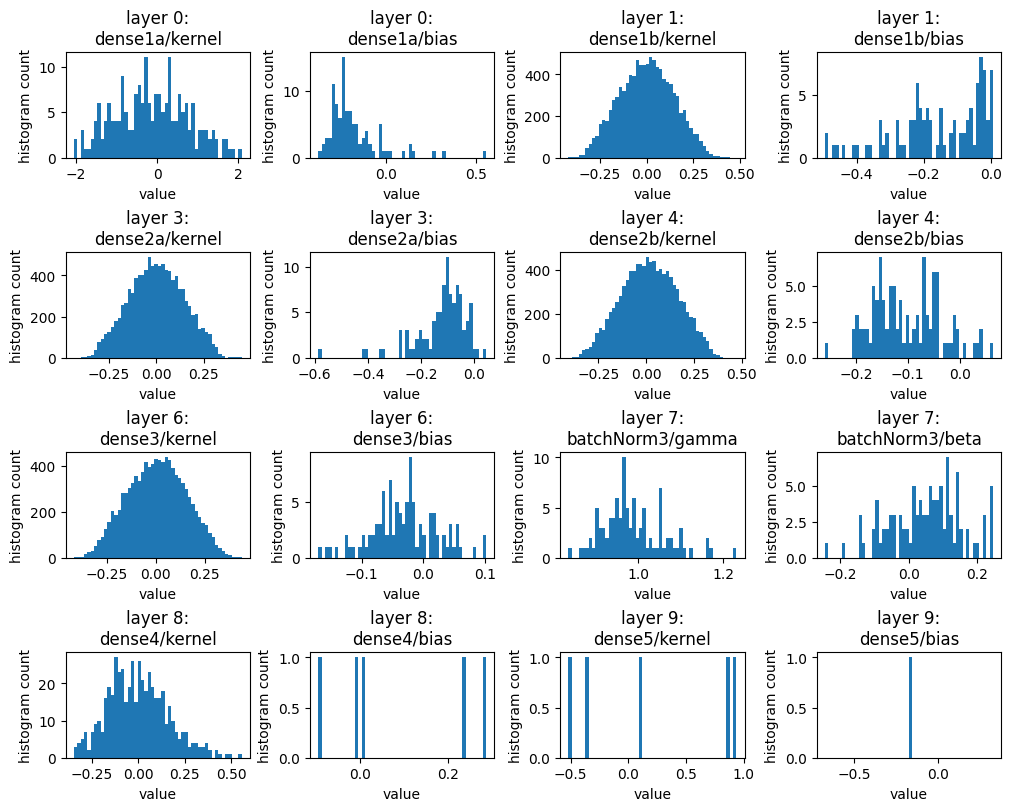

In [ ]:
plot_variable_histograms(model)

**Commentary**
* Your basic histograms work well for weights and biases. The distribution tends to stay within the bounds that they were initialized to.

**Experiment**

Now, what about for gradients?

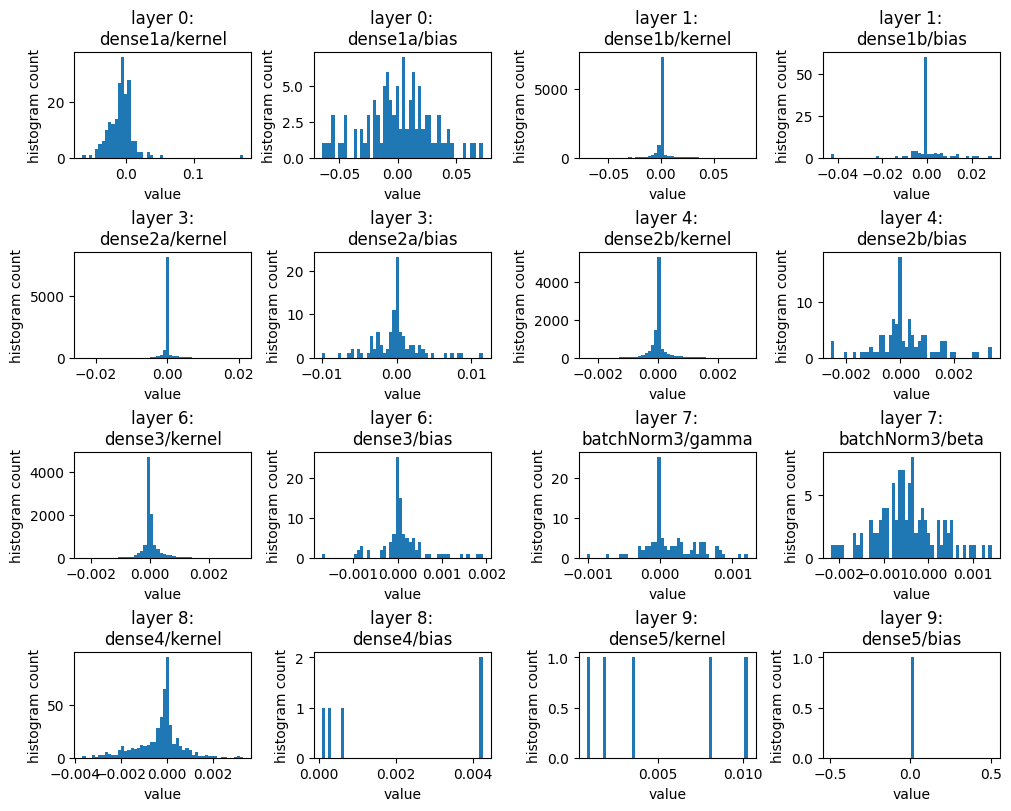

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((train_X, train_Y)).batch(32)
plot_gradient_histograms(model, dataset)

**Commentary**
* Gradients follow something more like a log-normal distribution, with positive/negative

## Plotting the weights and biases
There's several common ways of plotting weights:
* L2-norm aka euclidean norm (with/without size normalization)
* mean and stddev
* histograms

The following shows some of these options.


First, the L2-norm with size-normalization (ie: so that differently sized tensors still produce values on comparable scales), which is mathematically equivalent to calculating the RMS of the elements in each tensor:

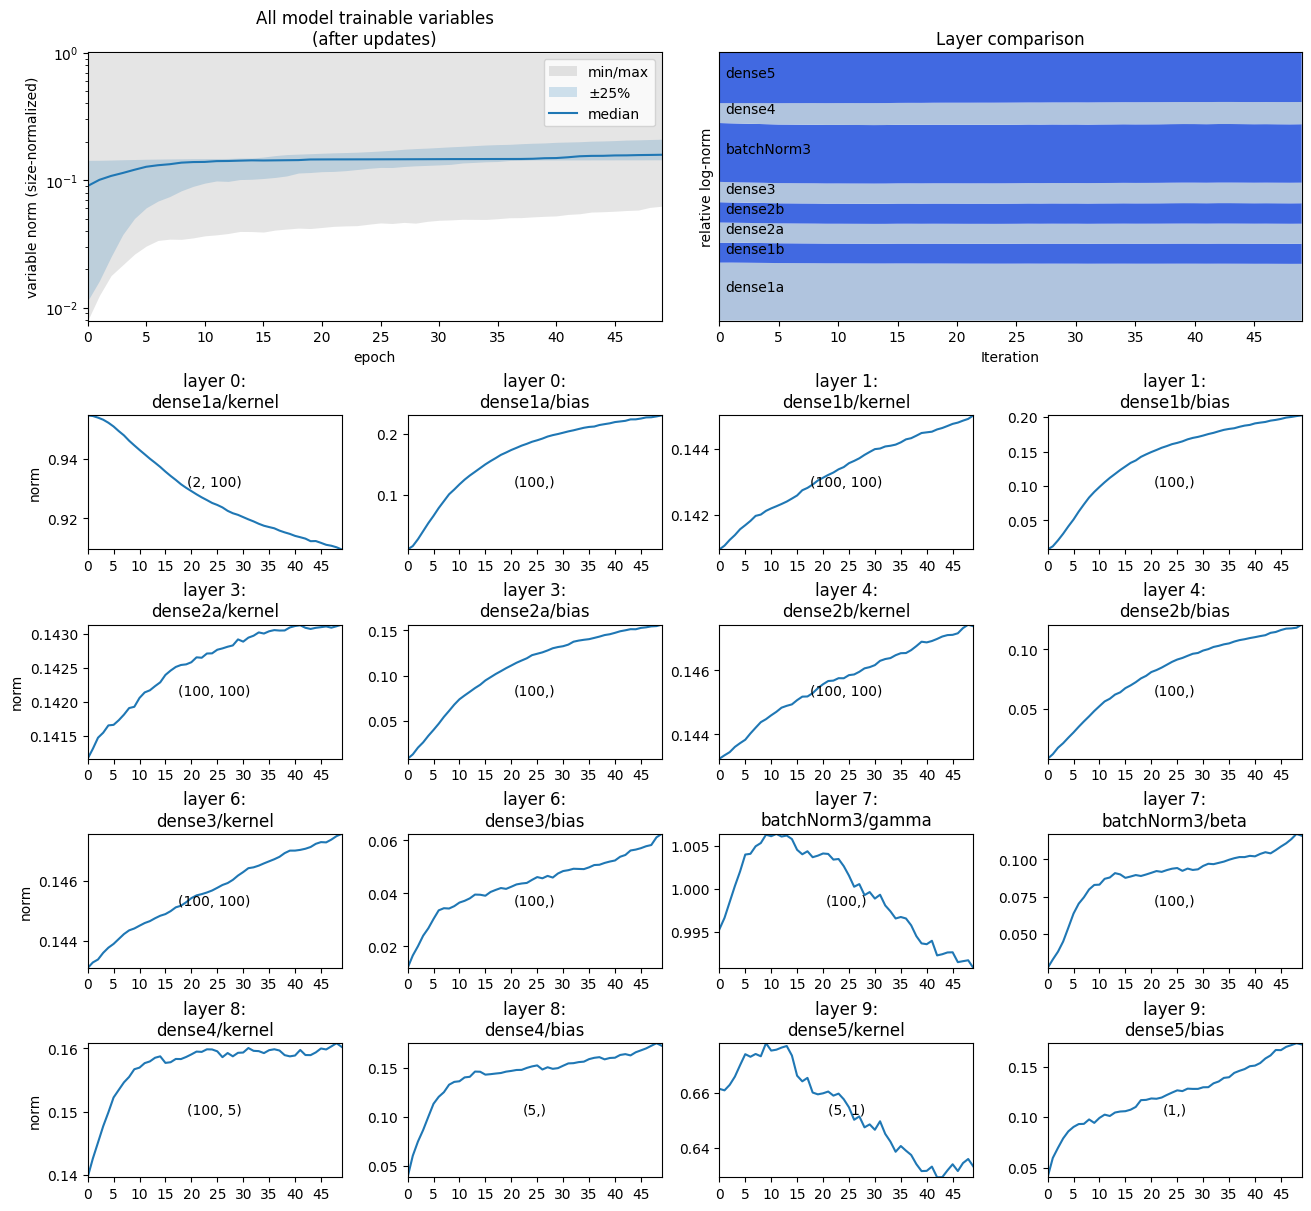

In [ ]:
tinstr.plot_value_history(variables, show='norms', yscale='linear')

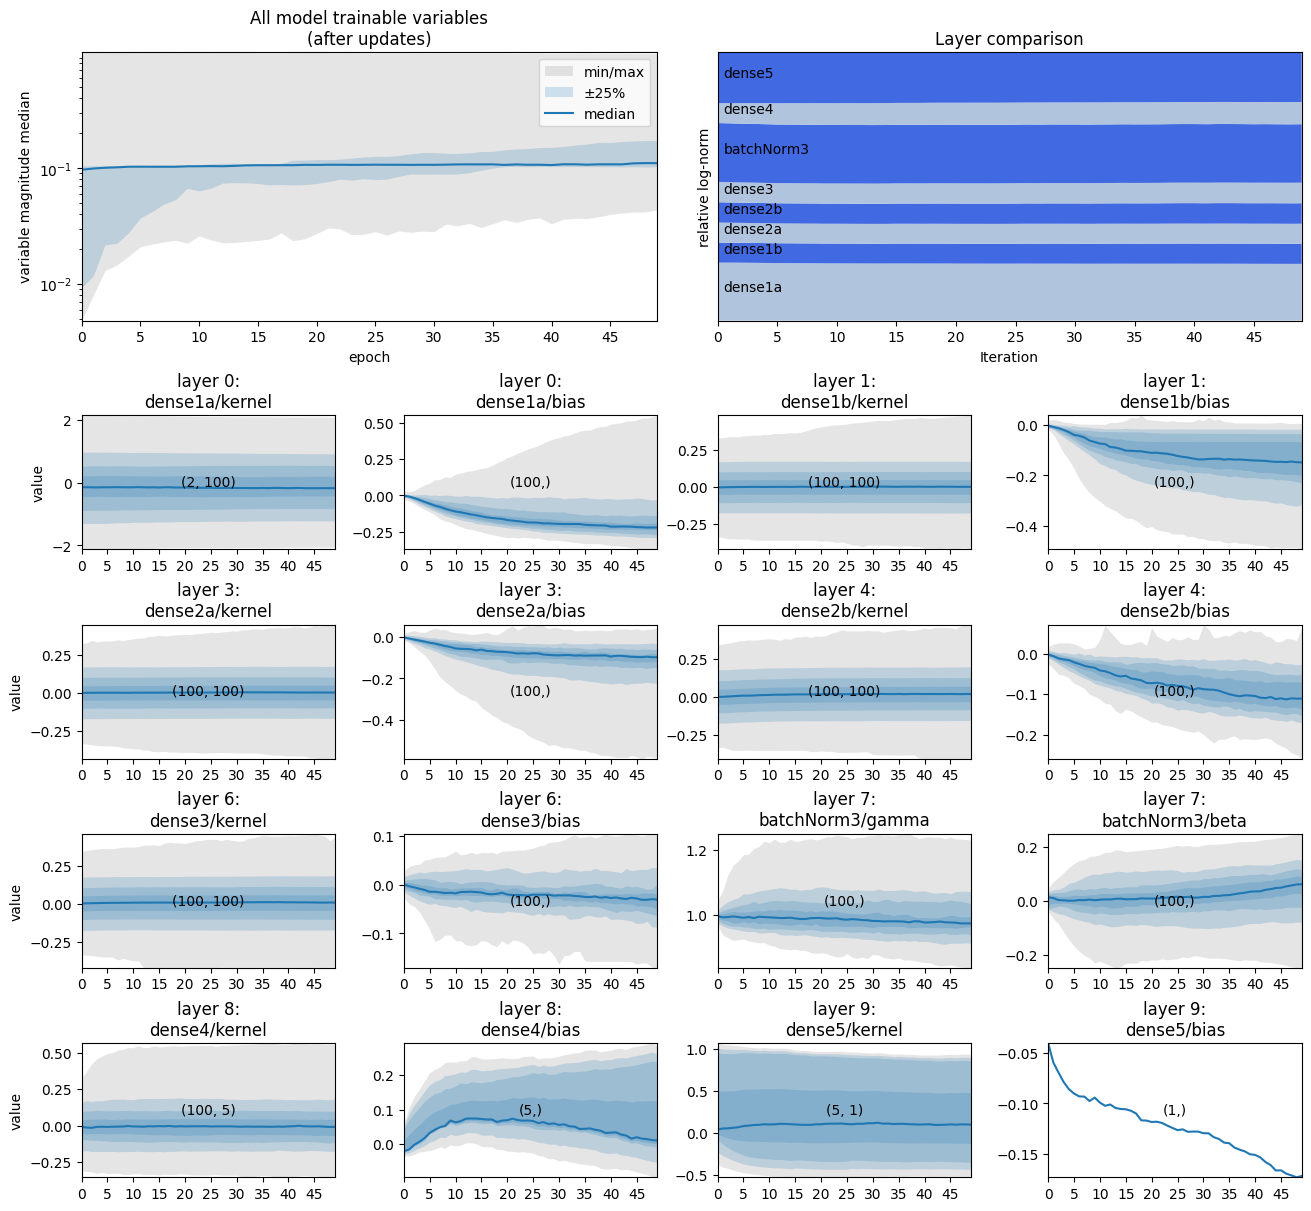

In [ ]:
tinstr.plot_value_history(variables, show='values')

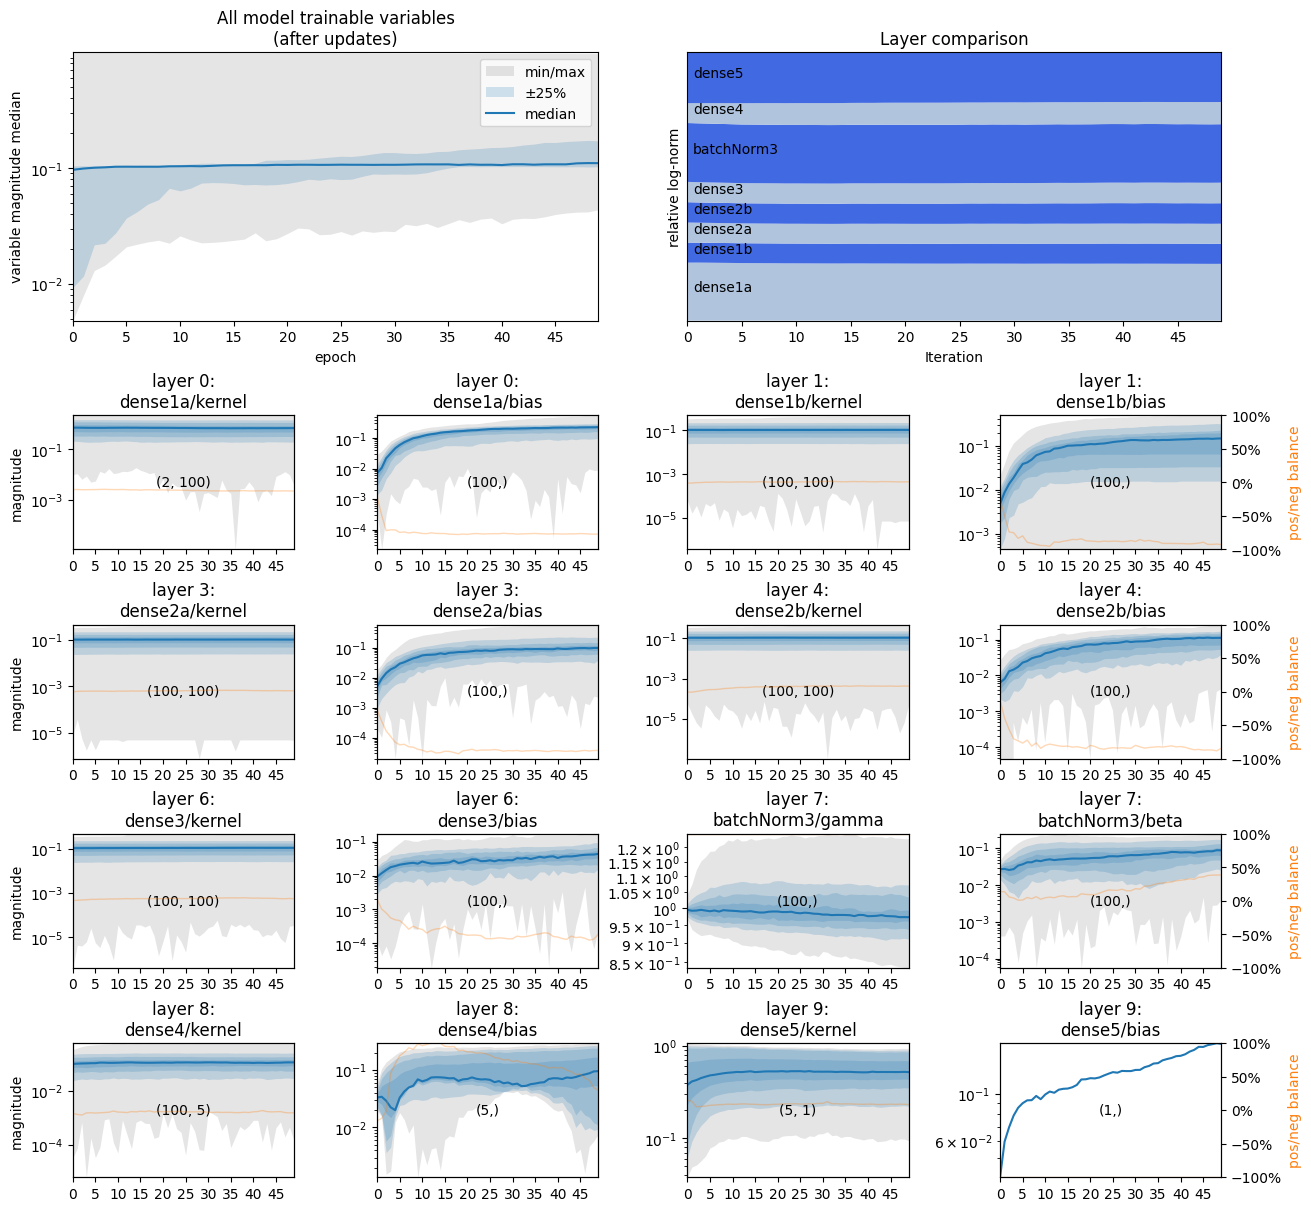

In [ ]:
tinstr.plot_value_history(variables, show='magnitudes')

**Commentary**
* The norms and value plots are quite intelligle for the model parameters.
* But that isn't usually the case for gradients....

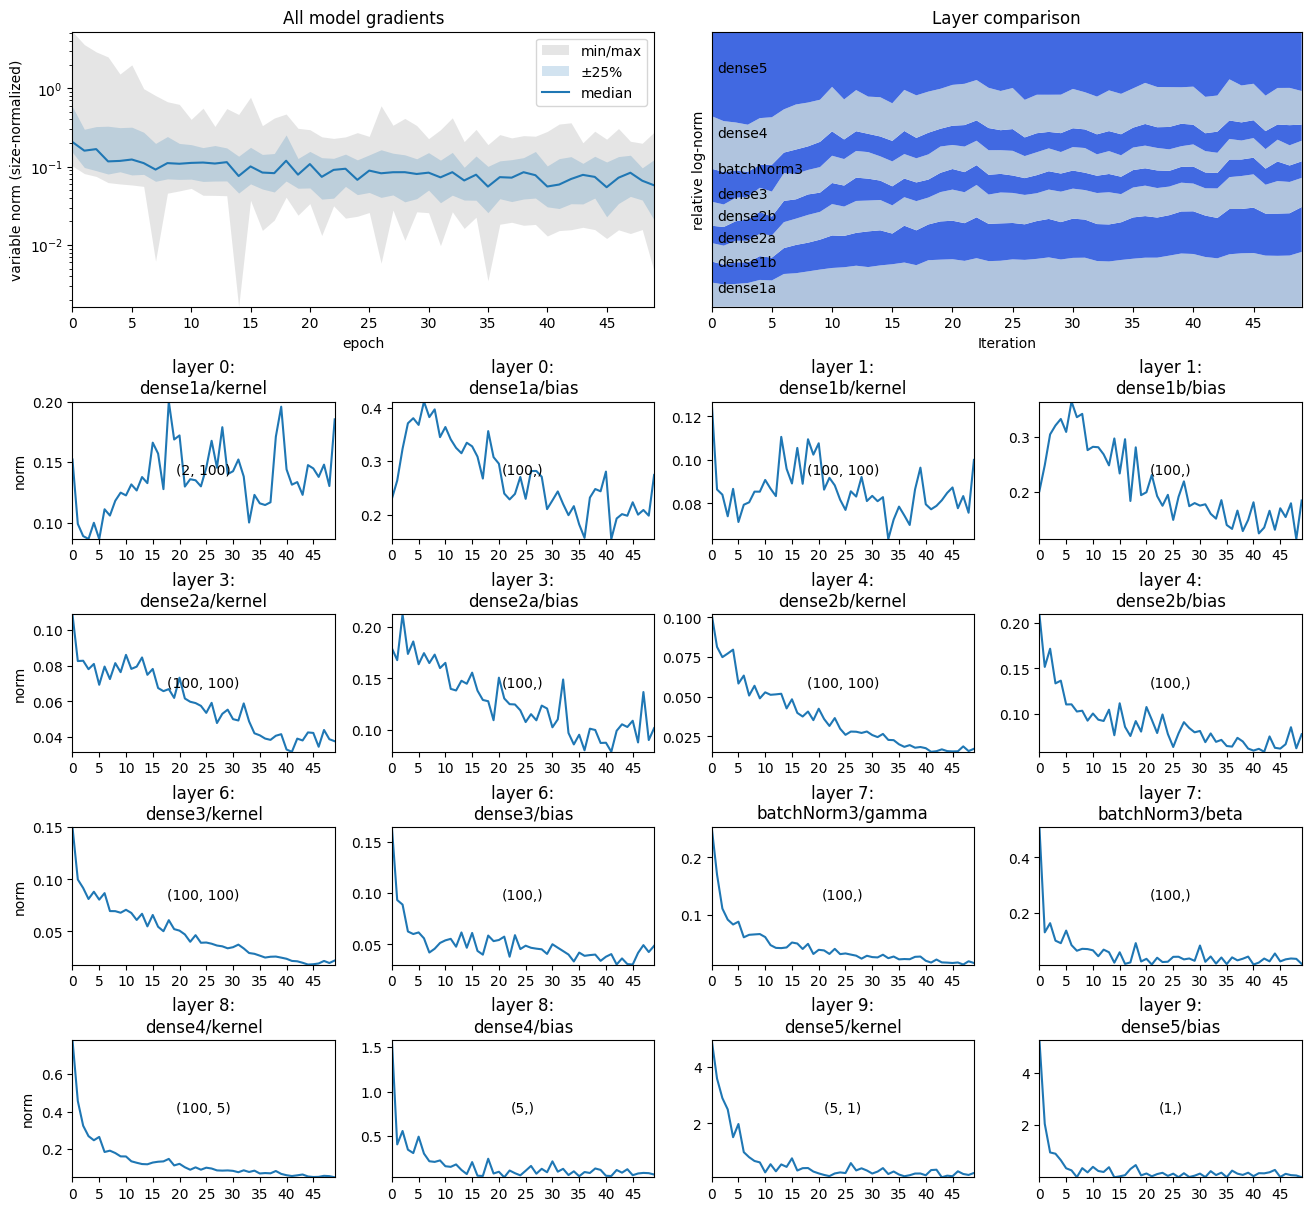

In [ ]:
tinstr.plot_value_history(gradients, show='norms', yscale='linear')

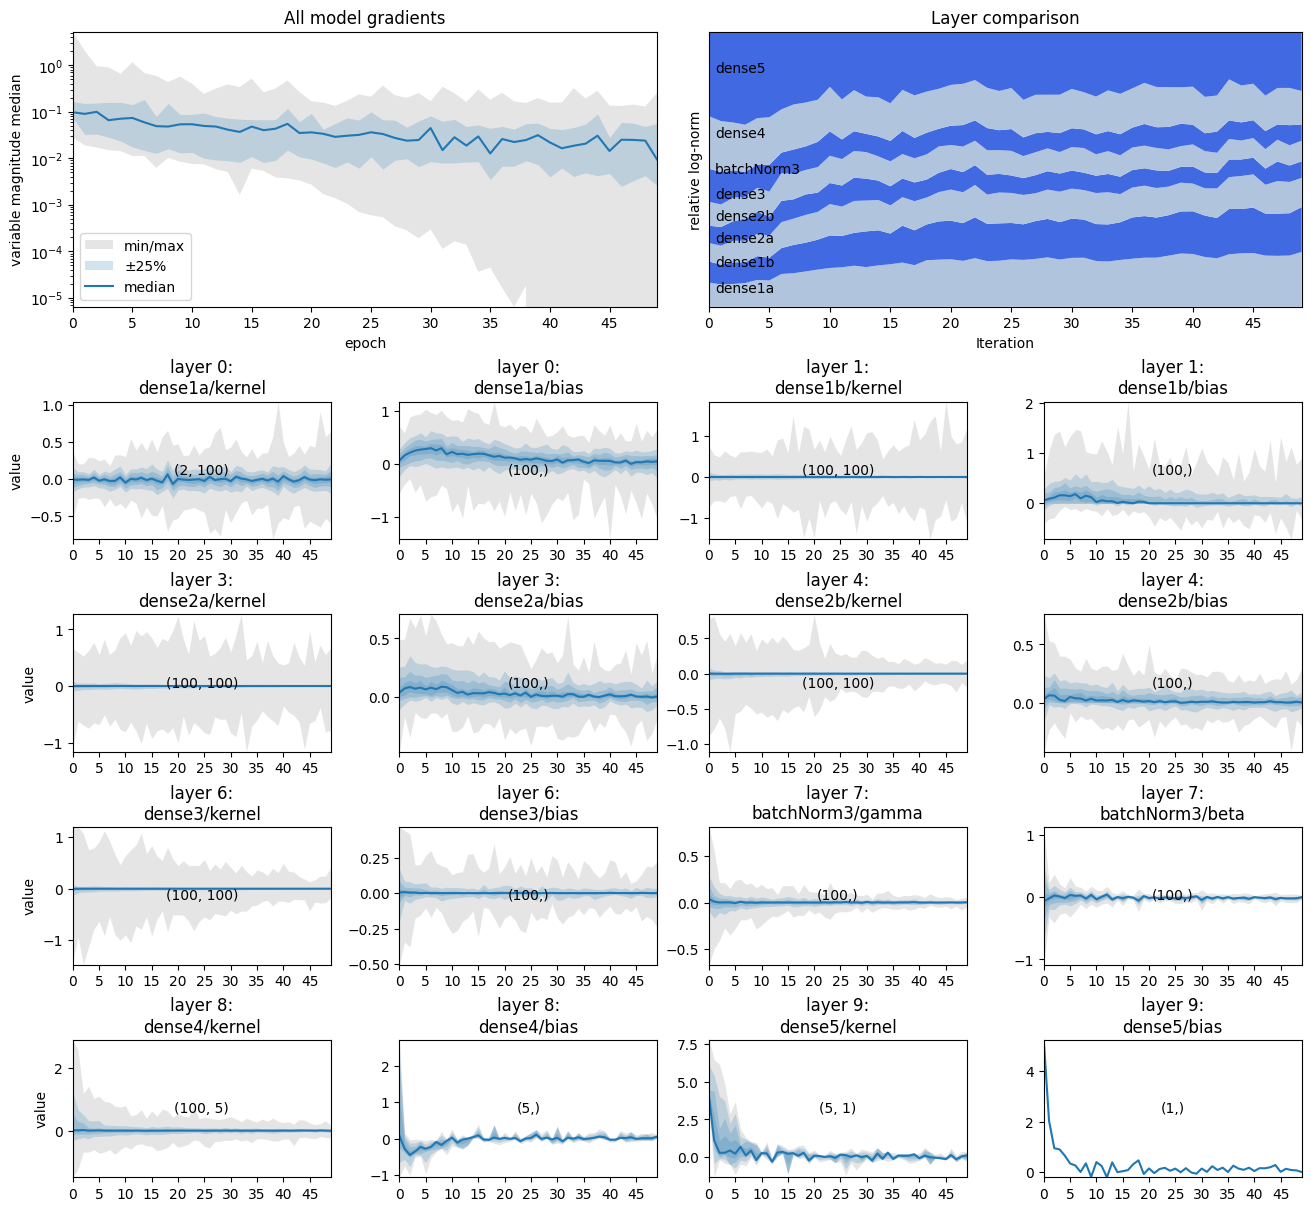

In [ ]:
tinstr.plot_value_history(gradients, show='values')

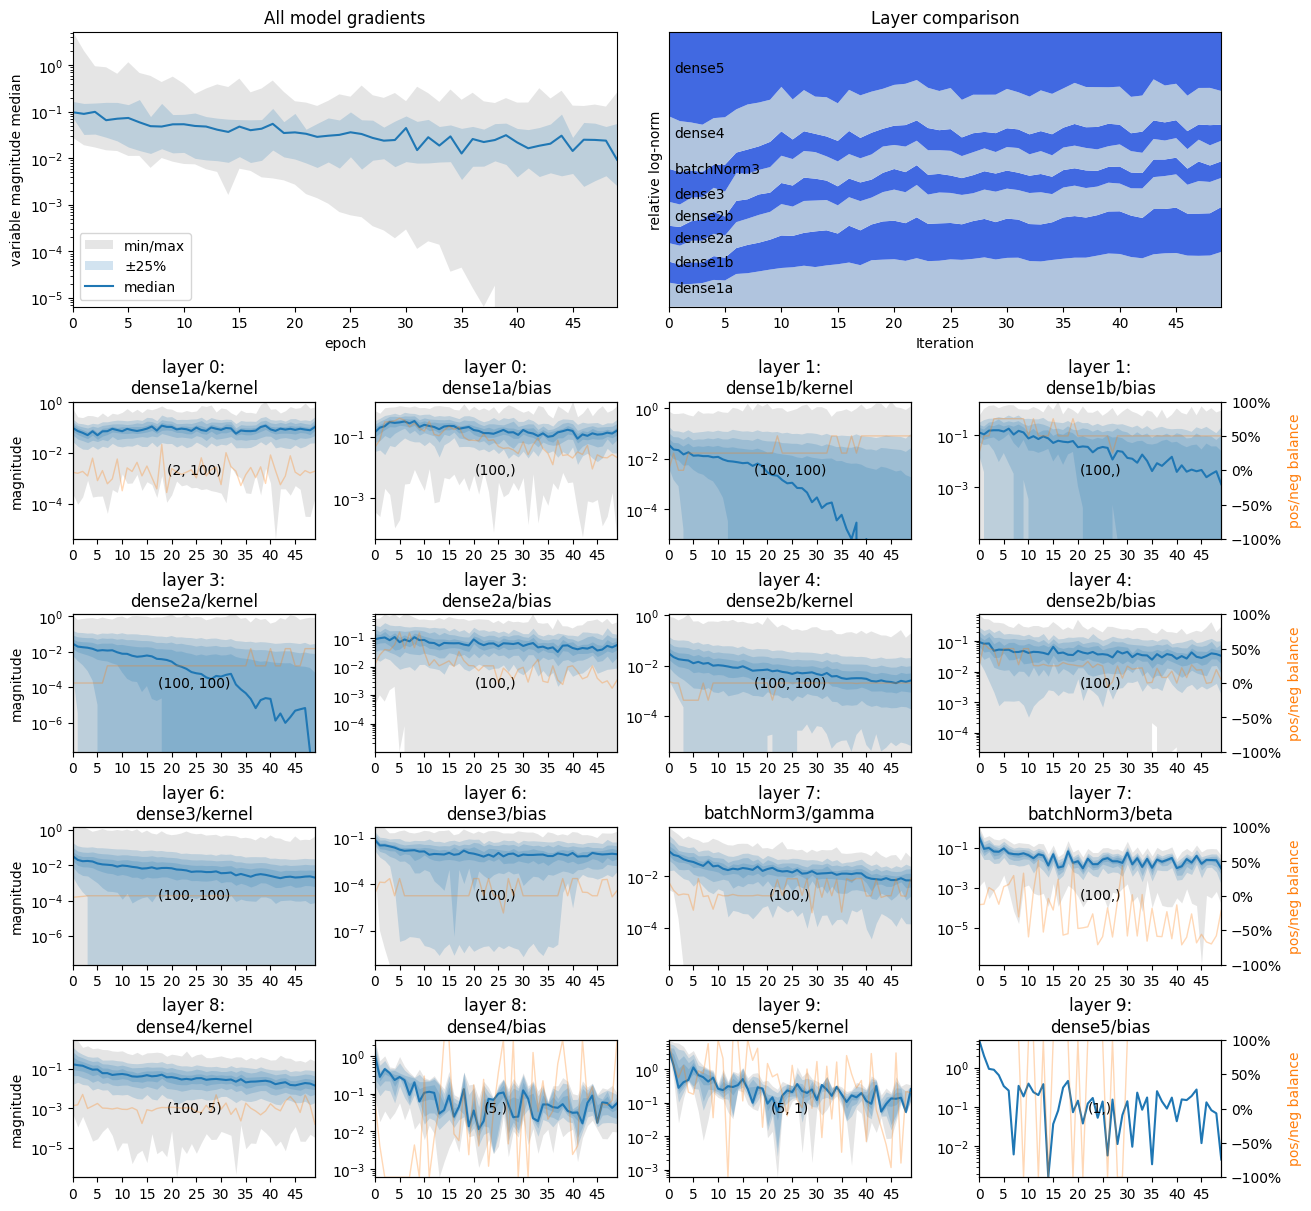

In [ ]:
tinstr.plot_value_history(gradients, show='magnitudes')

**Commentary**
* For gradients, you need to use a log-of-magnitudes plot.

## Distribution plots for Layer Outputs and their Gradients
It's also possible to generate these same plots for the layer outputs and their gradients.

One issue is that the layer output include the batch dimension, and vary from step to step. Unlike for gradients and weights, there's no simple natural way to calculate the full percentile distribution over the layer outputs over an entire epoch. It is however easy and efficient to calculate running statistics needed for mean and stddev. So the distribution plots that follow use mean and stddev and represent as percentiles - which is unfortunately less accurate than true percentile data.

Layer outputs first...

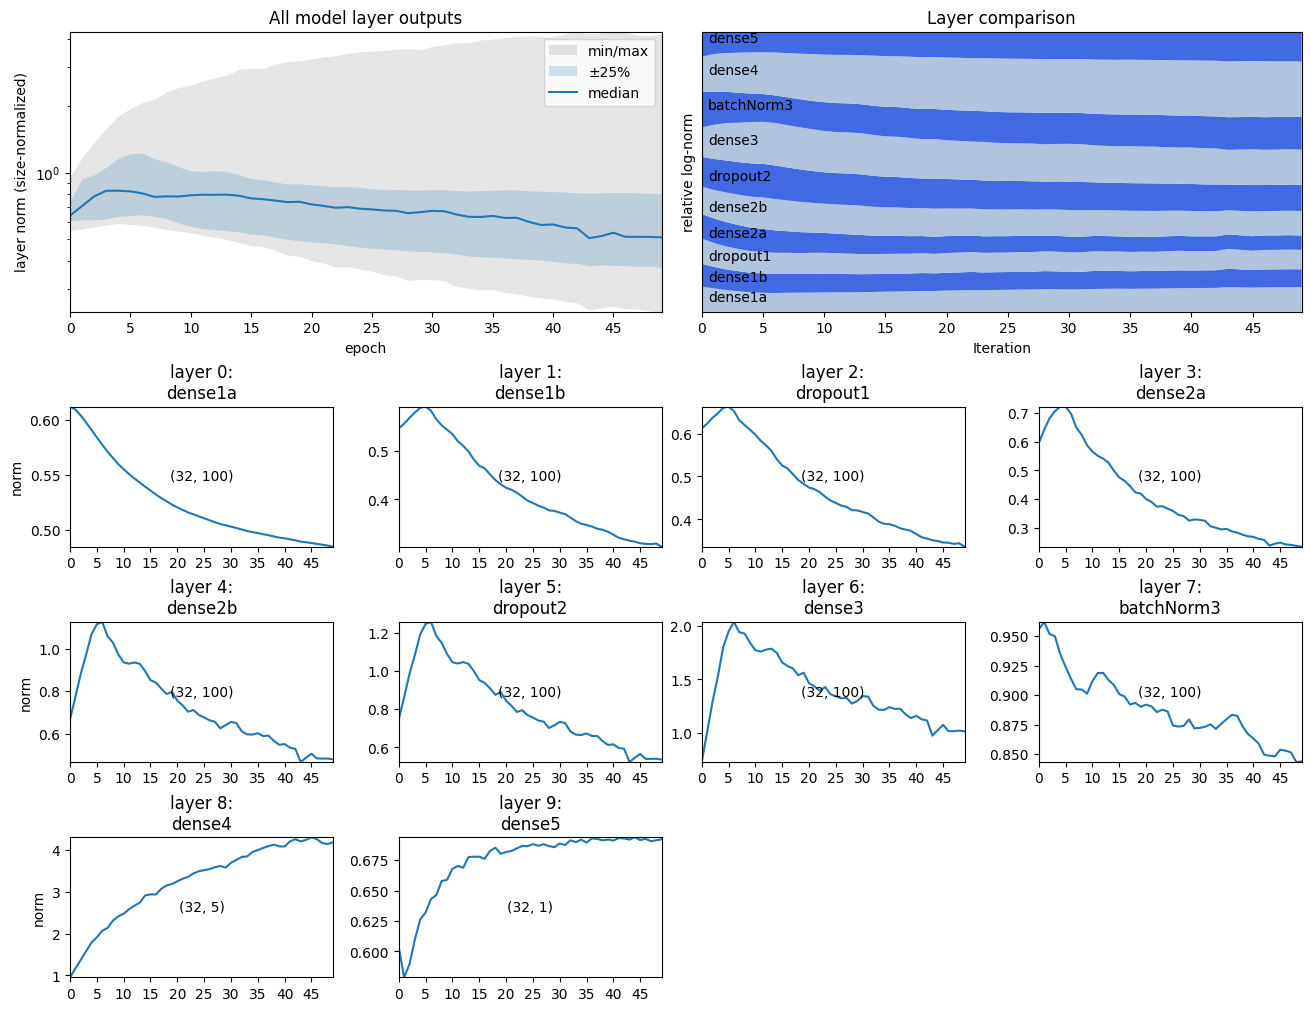

In [ ]:
tinstr.plot_value_history(outputs, show='norms', yscale='linear')

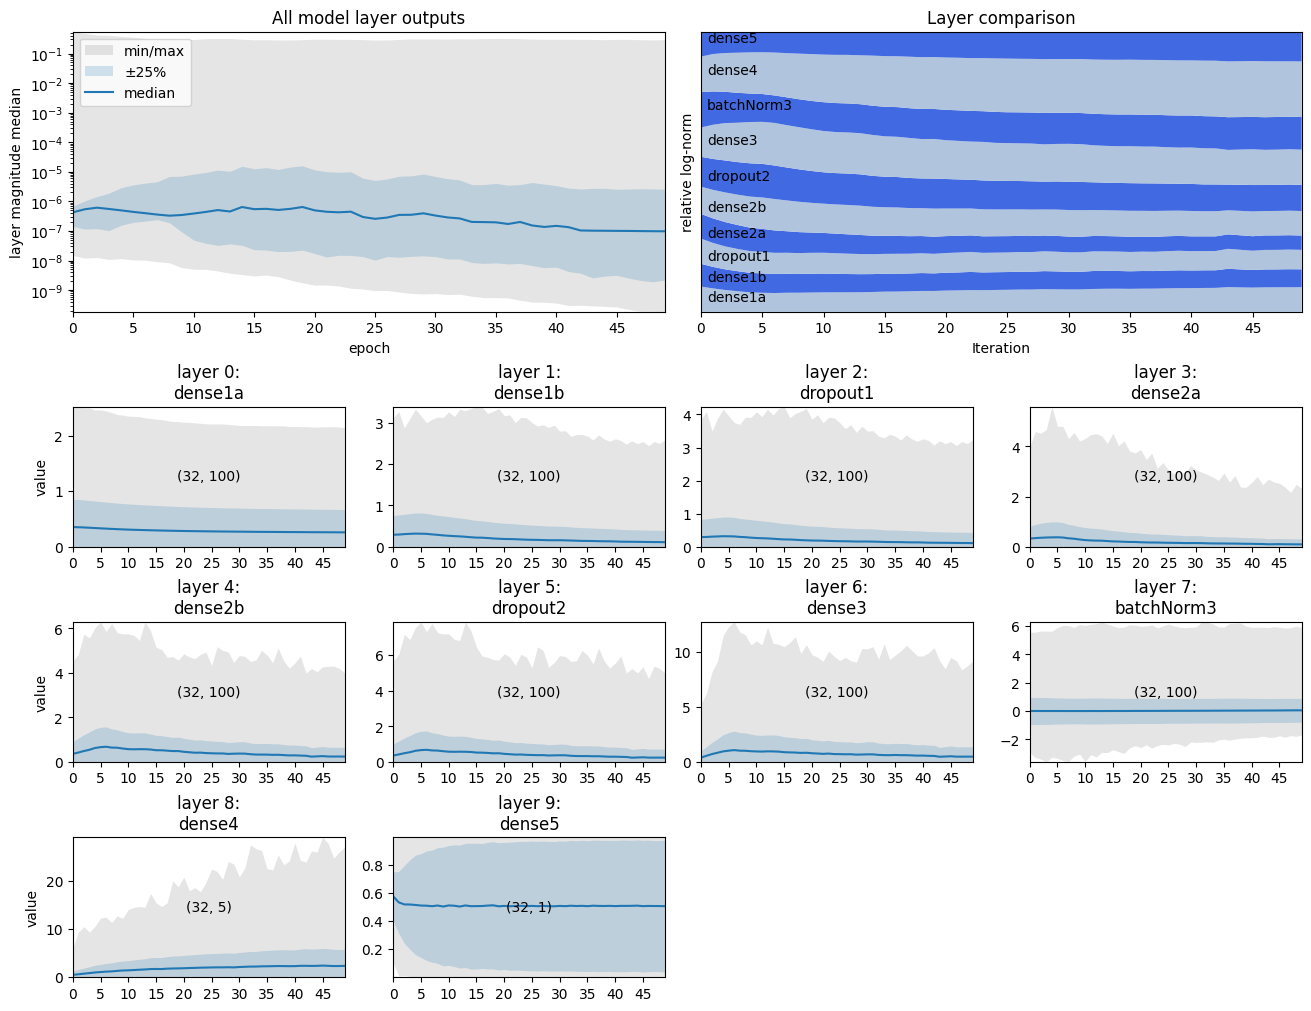

In [ ]:
tinstr.plot_value_history(outputs, show='values')

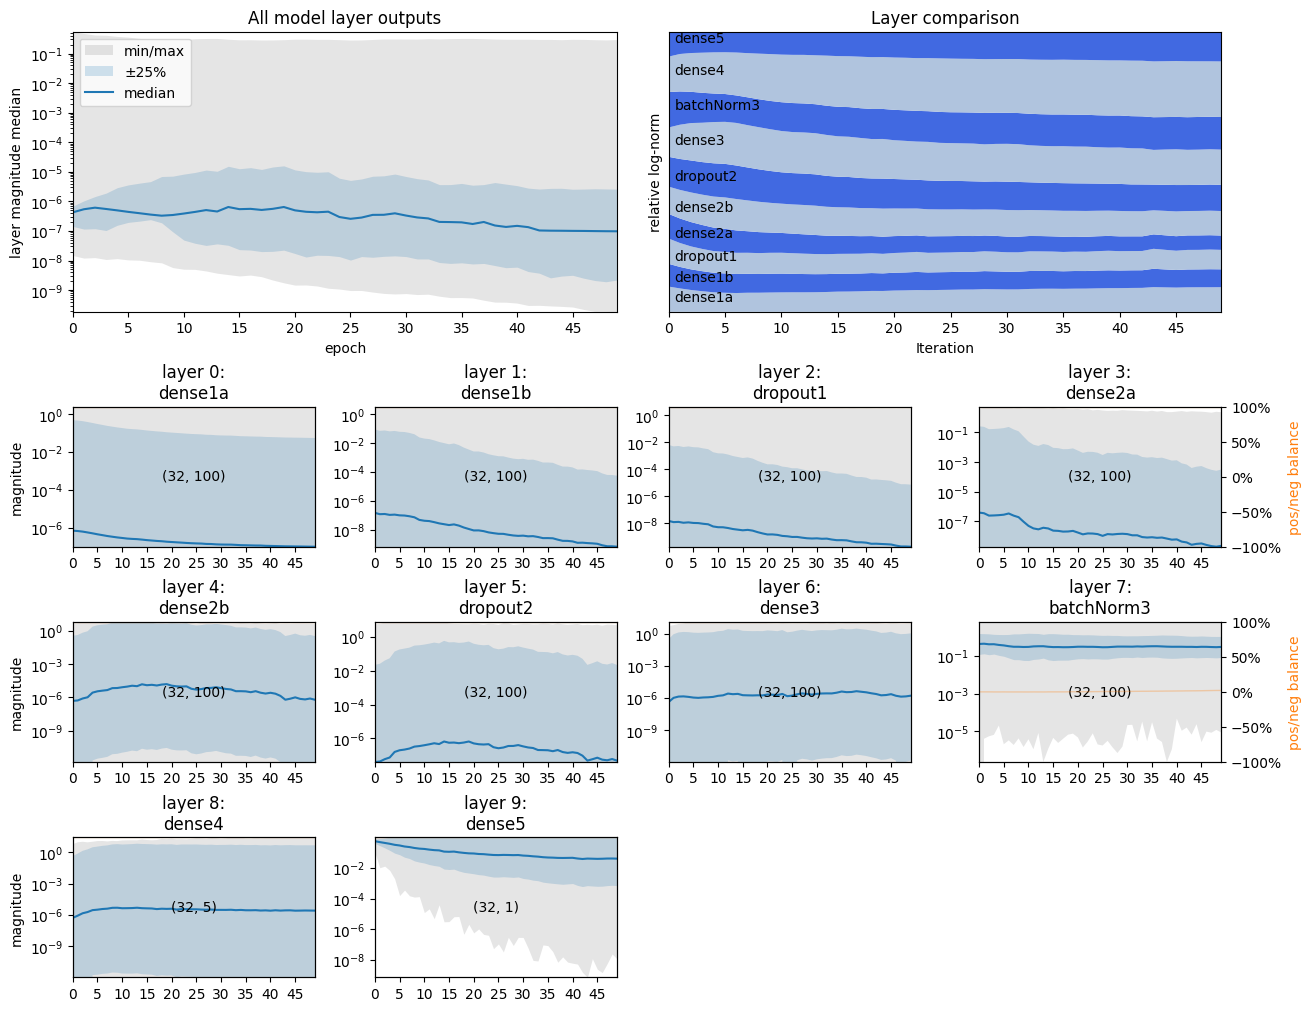

In [ ]:
tinstr.plot_value_history(outputs, show='magnitudes')

**Commentary**
* Notice how most layers only output positives, as per the ReLU activation function.
* And lastly, for the output gradients...

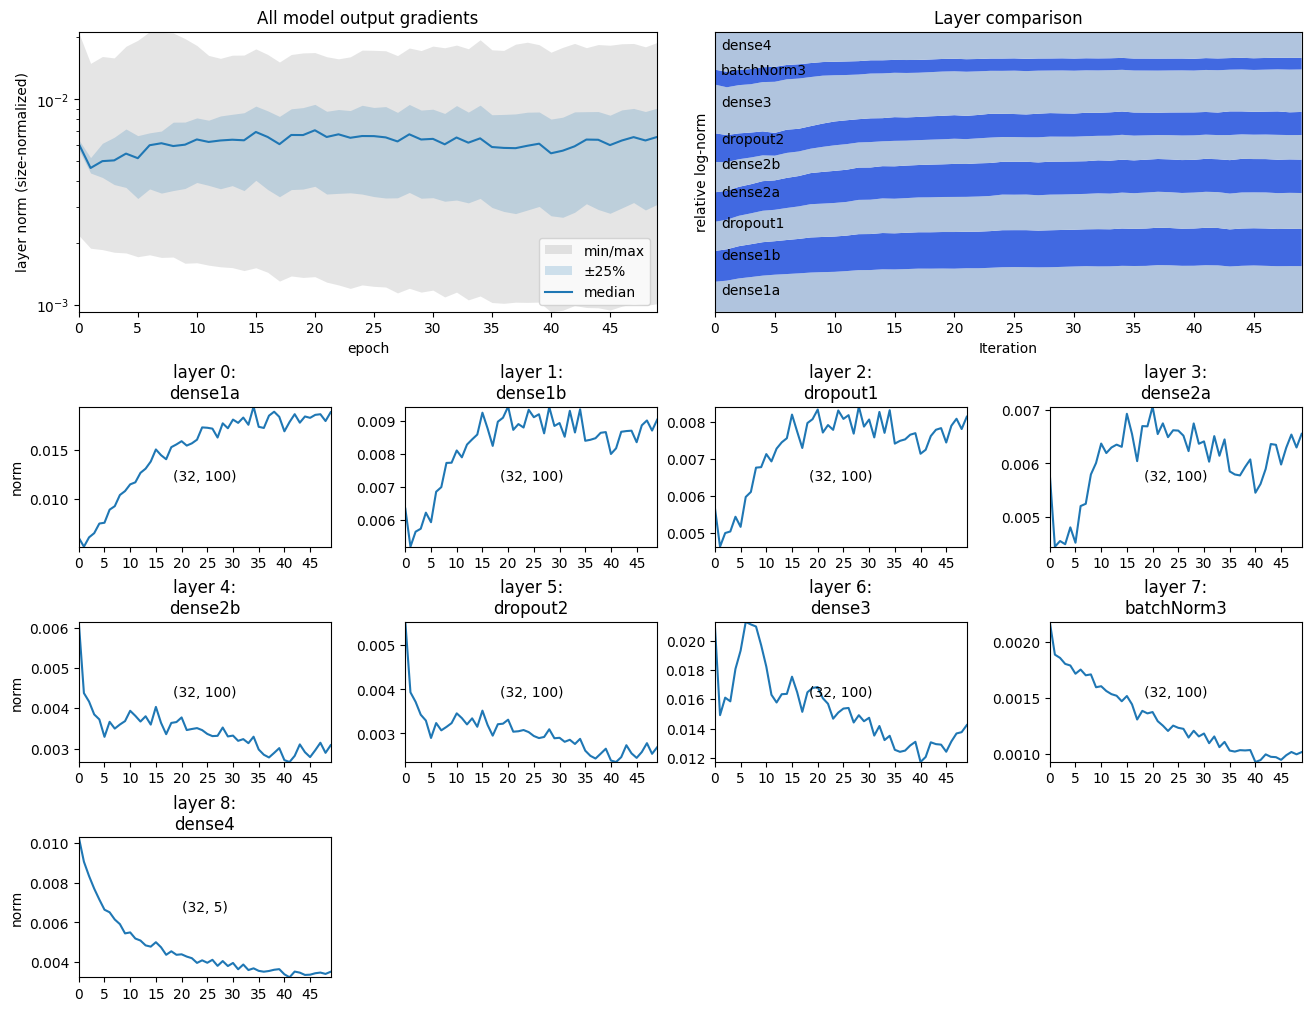

In [ ]:
tinstr.plot_value_history(output_gradients, show='norms', yscale='linear')

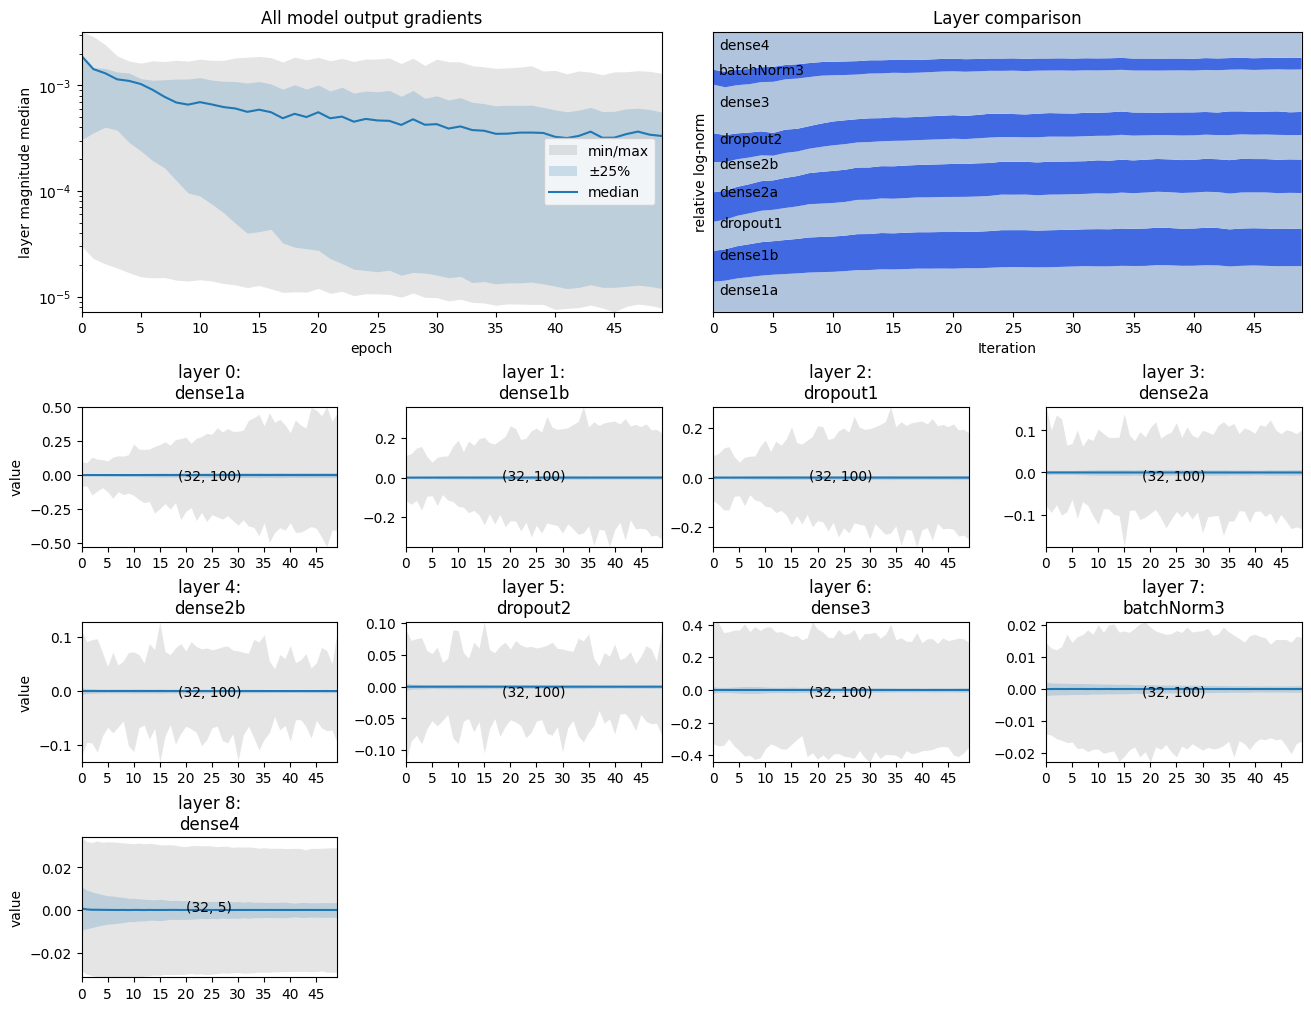

In [ ]:
tinstr.plot_value_history(output_gradients, show='values')

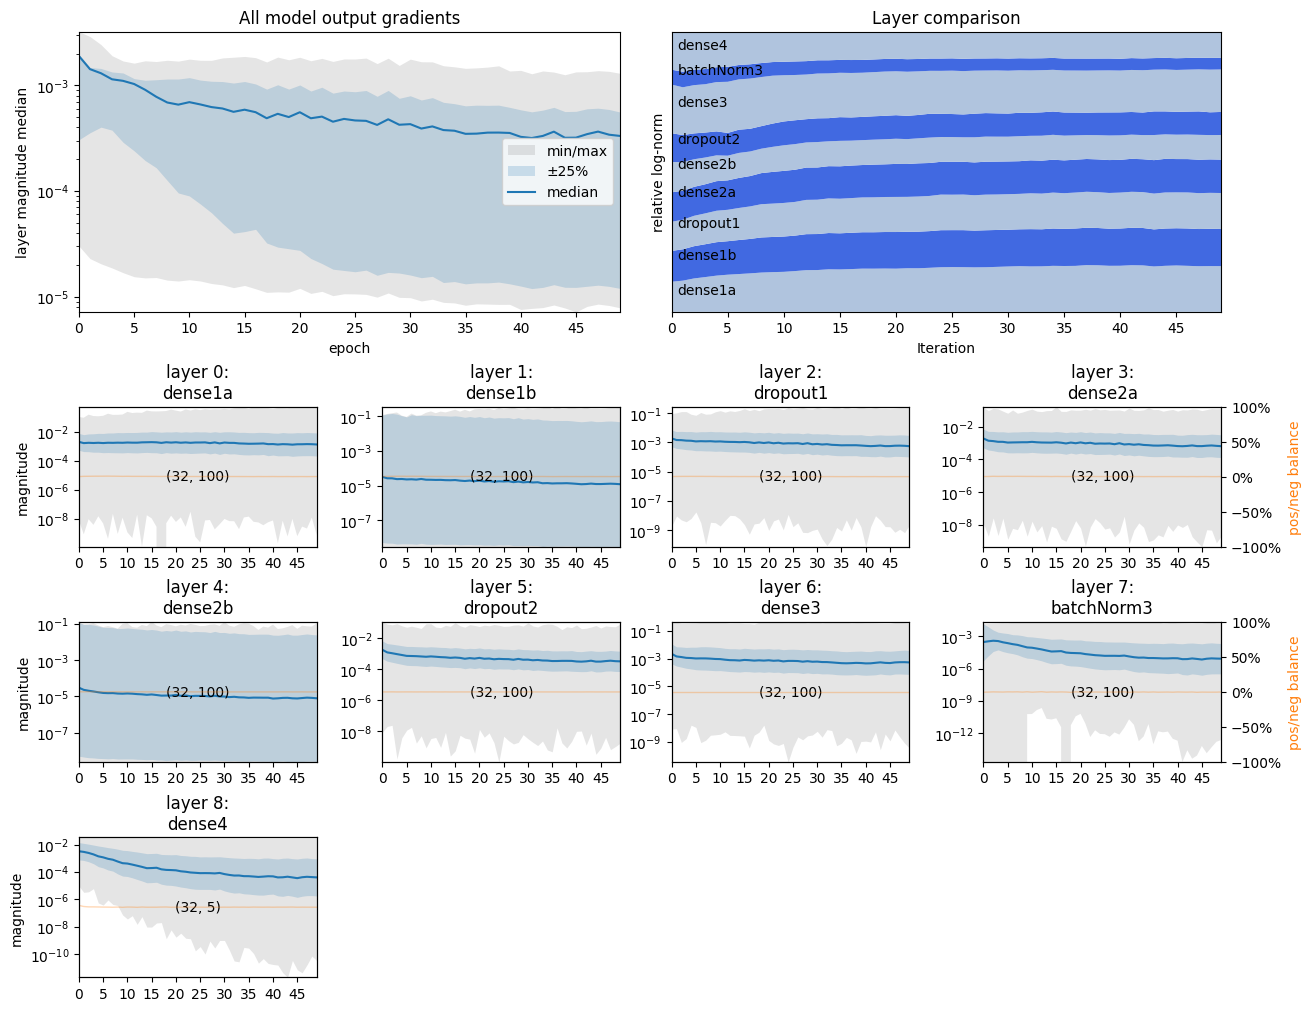

In [ ]:
tinstr.plot_value_history(output_gradients, show='magnitudes')

## MNIST classification
The above was for a binary classification problem on simple 2-coord data. Perhaps these plots will give different kinds of results on a completely different kind of model.

So let's try training a model against the MNIST dataset.

In [ ]:
def mnist_dataset(train_size=5000, test_size=1000):
  """
  Uses a subset of the MNIST dataset, for faster training.
  We're interested in the visualization of results, not in getting the most accurate model.
  Note that the mnist data tends to be well shuffled already, so blindly taking the first N samples works well
  enough for our needs here.
  """
  (train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()
  #class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

  # pre-process into the correct data range and just use the first 5000 images
  train_images = train_images / 255.0
  test_images = test_images / 255.0

  # take first N samples
  if train_size is not None:
    train_images = train_images[0:train_size]
    train_labels = train_labels[0:train_size]
  if test_size is not None:
    test_images = test_images[0:test_size]
    test_labels = test_labels[0:test_size]

  print(f"train: inputs={train_images.shape}, labels={train_labels.shape}")
  print(f"test:  inputs={test_images.shape}, labels={test_labels.shape}")

  train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels)).batch(32)
  test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels)).batch(32)
  return train_dataset, test_dataset

In [ ]:
def mnist_classification_model():
  inp = tf.keras.layers.Input((28, 28), name="input")
  x = tf.keras.layers.Reshape((28,28,1), name="reshape")(inp)

  x = tf.keras.layers.Conv2D(filters=16, kernel_size=3, activation='relu', kernel_initializer='he_normal', name="conv1a")(x)
  x = tf.keras.layers.Conv2D(filters=16, kernel_size=3, activation='relu', kernel_initializer='he_normal', name="conv1b")(x)
  x = layers.BatchNormalization(name="batchNorm1")(x)
  x = tf.keras.layers.MaxPool2D(pool_size=2, padding='valid', name="pool1")(x)
  x = layers.Dropout(0.2, name="dropout1")(x)

  x = tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', kernel_initializer='he_normal', name="conv2a")(x)
  x = tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', kernel_initializer='he_normal', name="conv2b")(x)
  x = layers.BatchNormalization(name="batchNorm2")(x)
  x = tf.keras.layers.MaxPool2D(pool_size=2, padding='valid', name="pool2")(x)
  x = layers.Dropout(0.2, name="dropout2")(x)

  x = tf.keras.layers.Flatten(name="flatten")(x)
  x = tf.keras.layers.Dense(units=128, activation='relu', kernel_initializer='he_normal', name="dense1")(x)
  x = tf.keras.layers.Dense(units=128, activation='relu', kernel_initializer='he_normal', name="dense2")(x)
  x = tf.keras.layers.Dense(units=10, kernel_initializer='glorot_normal', name="logits")(x)
  return tf.keras.Model(inputs=inp, outputs=x)

mnist_classification_model().summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1a (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 24, 24, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchNorm1 (BatchNormalization) │ (None, 24, 24, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 10, 10, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchNorm2 (BatchNormalization) │ (None, 8, 8, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,026 (390.73 KB)

 Trainable params: 99,930 (390.35 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:
tf.keras.utils.set_random_seed(1)

# Run a full training sequence and collect default information for each of the four main callbacks.
# We'll also use the extended `HistoryStats` callback for loss and metric history.
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = mnist_classification_model()
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
train_dataset, val_dataset = mnist_dataset()
history = tinstr.fit(model, train_dataset, validation_data=val_dataset, epochs=20, verbose=0,
                     callbacks=[tinstr.LessVerboseProgressLogger(), variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

# PS: any tf.function retracing warnings can be safely ignored.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train: inputs=(5000, 28, 28), labels=(5000,)
test:  inputs=(1000, 28, 28), labels=(1000,)


Epoch     2 - 14.54s/epoch: accuracy: 0.7898  loss: 0.5507  val_accuracy: 0.7030  val_loss: 0.8192  
Epoch     4 - 6.05s/epoch: accuracy: 0.8414  loss: 0.4161  val_accuracy: 0.8260  val_loss: 0.4866  
Epoch     6 - 5.68s/epoch: accuracy: 0.8726  loss: 0.3403  val_accuracy: 0.8530  val_loss: 0.4385  
Epoch     8 - 5.62s/epoch: accuracy: 0.8926  loss: 0.2905  val_accuracy: 0.8490  val_loss: 0.4736  
Epoch    10 - 5.38s/epoch: accuracy: 0.9032  loss: 0.2525  val_accuracy: 0.8550  val_loss: 0.4583  
Epoch    12 - 5.53s/epoch: accuracy: 0.9136  loss: 0.2184  val_accuracy: 0.8550  val_loss: 0.4805  
Epoch    14 - 5.65s/epoch: accuracy: 0.9274  loss: 0.1882  val_accuracy: 0.8620  val_loss: 0.4465  
Epoch    16 - 5.63s/epoch: accuracy: 0.9318  loss: 0.1710  val_accuracy: 0.8530  val_loss: 0.4856  
Epoch    18 - 5.61s/epoch: accuracy: 0.9426  loss: 0.1491  val_accuracy: 0.8440  val_loss: 0.5000  
Epoch    20 - 5.68s/epoch: accuracy: 0.9410  loss: 0.1542  val_accuracy: 0.8600  val_loss: 0.5057  

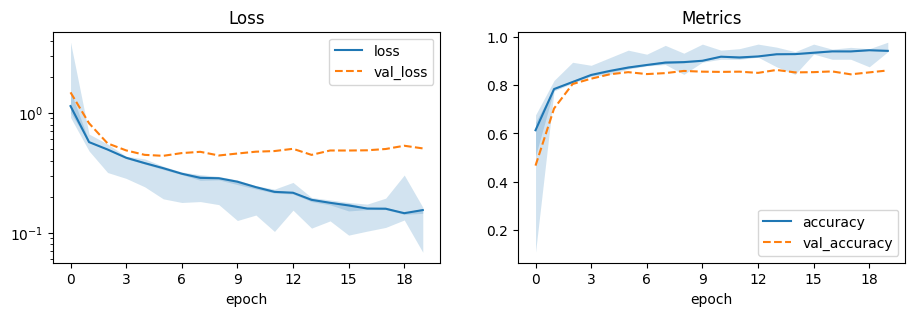

In [ ]:
tinstr.plot_train_history(history)

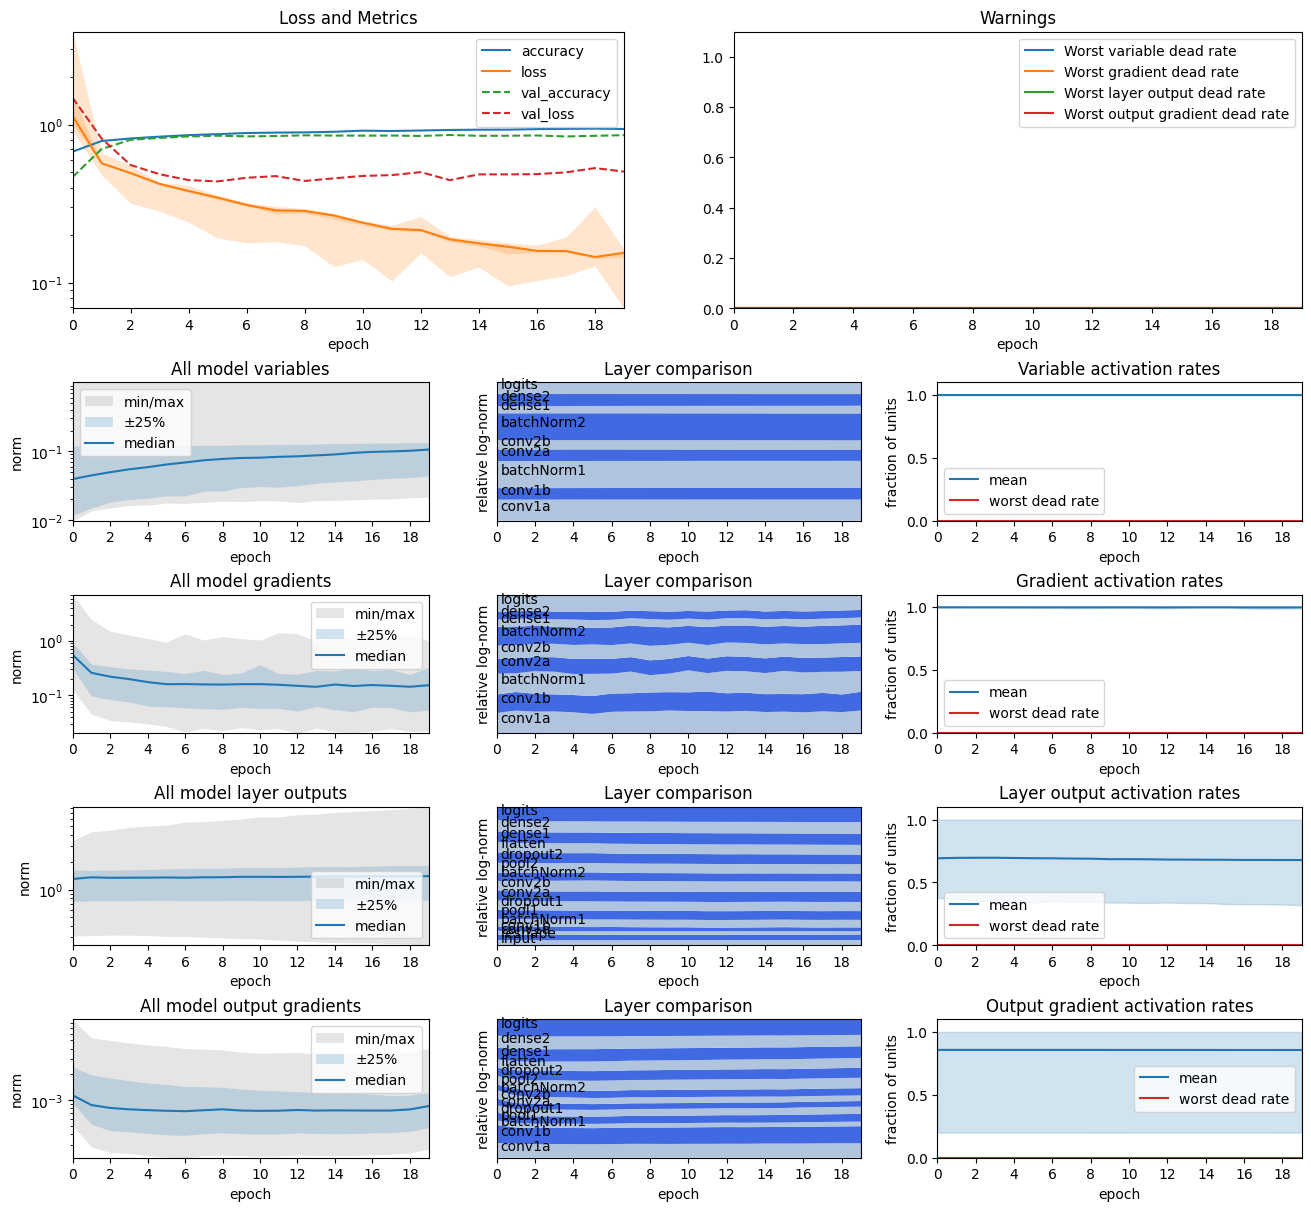

In [ ]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

The distribution of weights and biases on the initialized model:

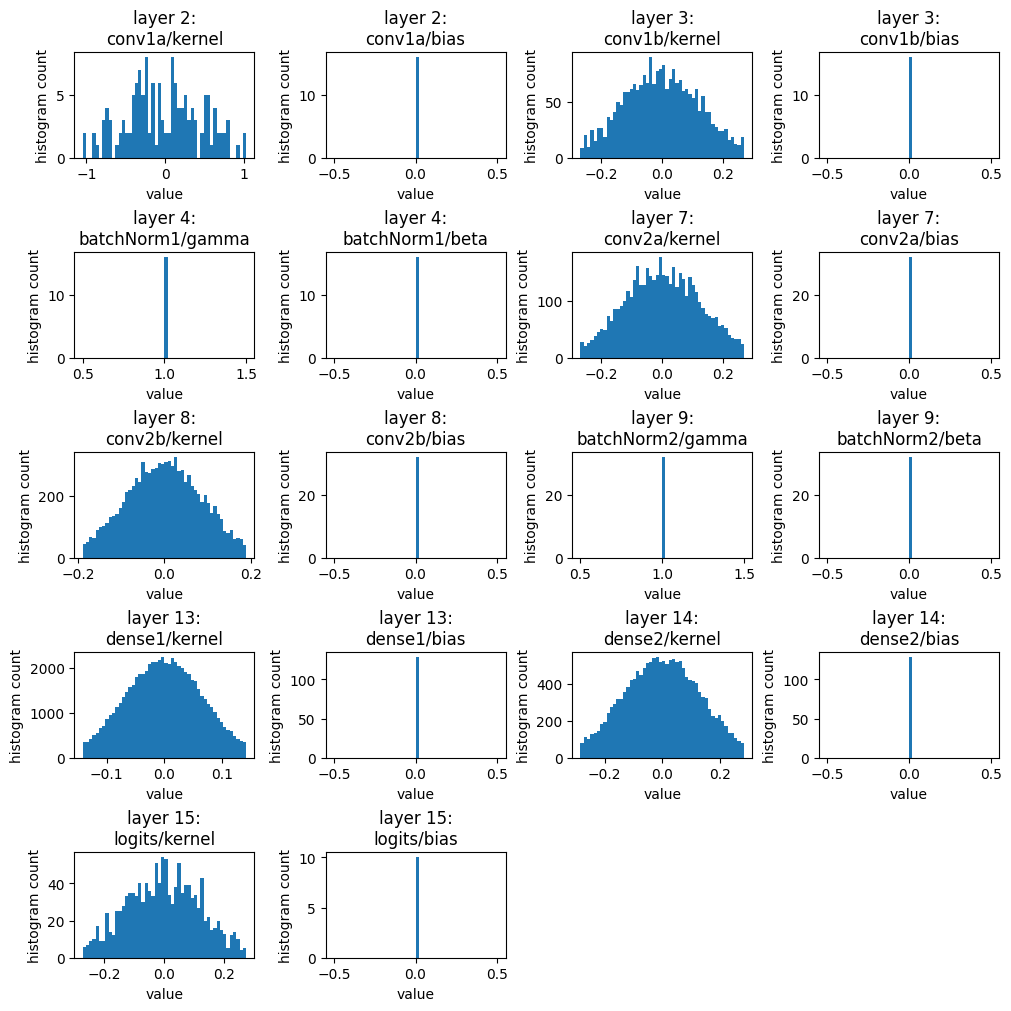

In [ ]:
plot_variable_histograms(mnist_classification_model())

The distribution of weight and biases on the trained model:

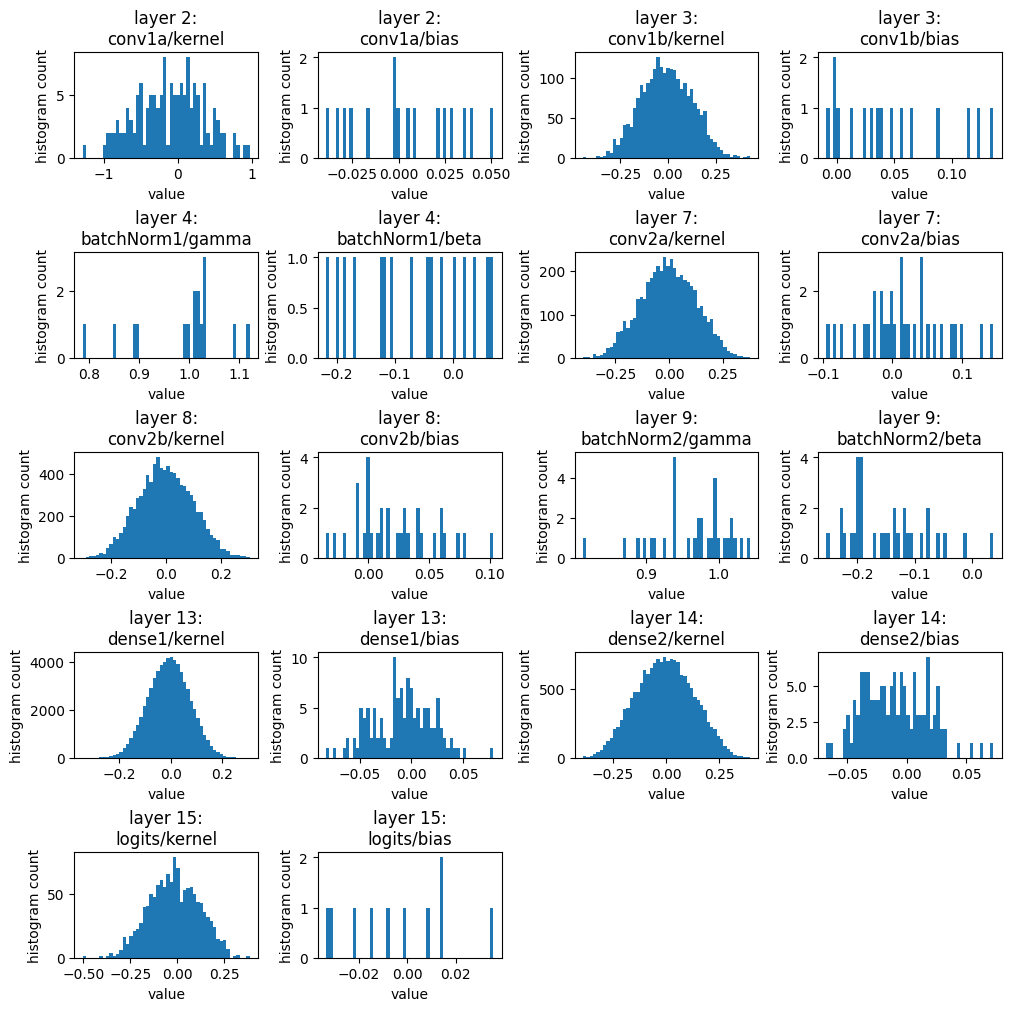

In [ ]:
plot_variable_histograms(model)

The distribution of gradients on the trained model:

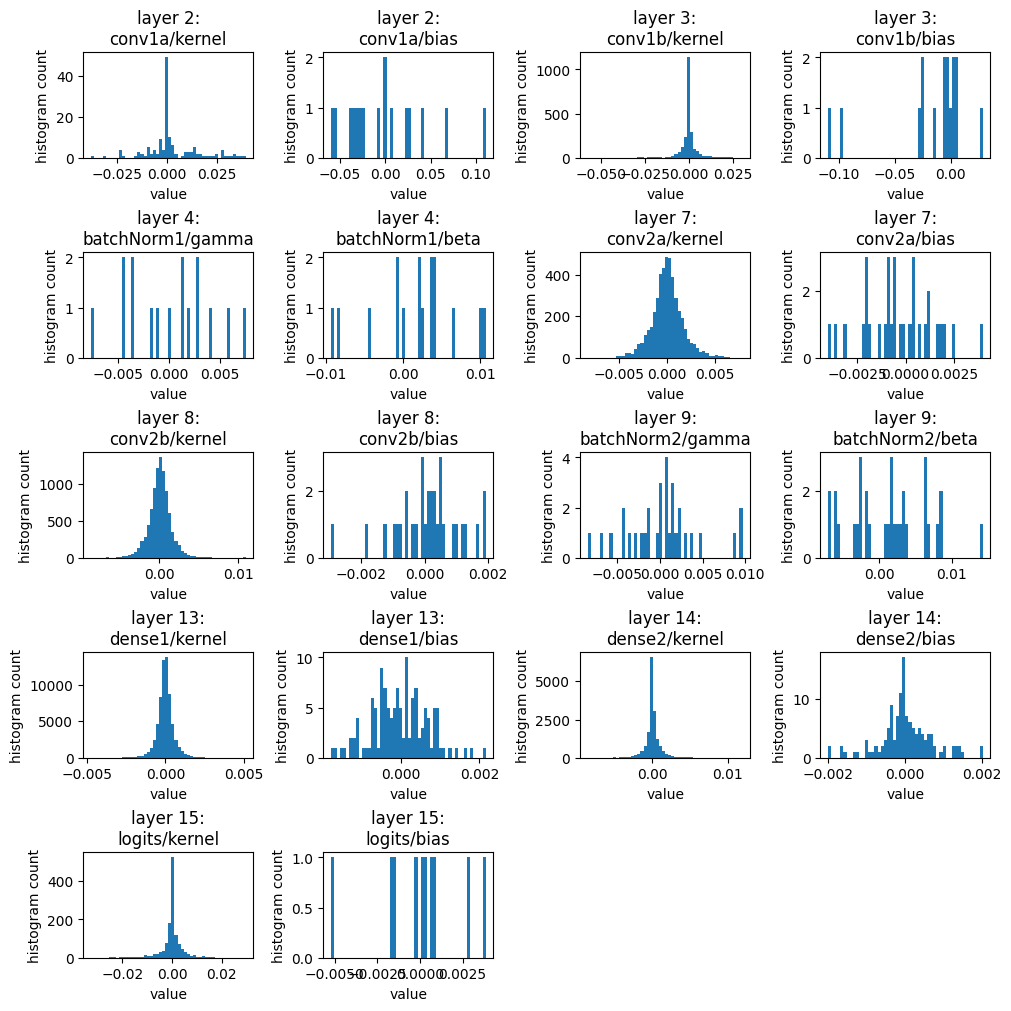

In [ ]:
plot_gradient_histograms(model, train_dataset)

**Commentary**
* The general trend of gradients is as per before - very narrow/sharp peaks, with very wide bases. Not suitable for simple linear plots.

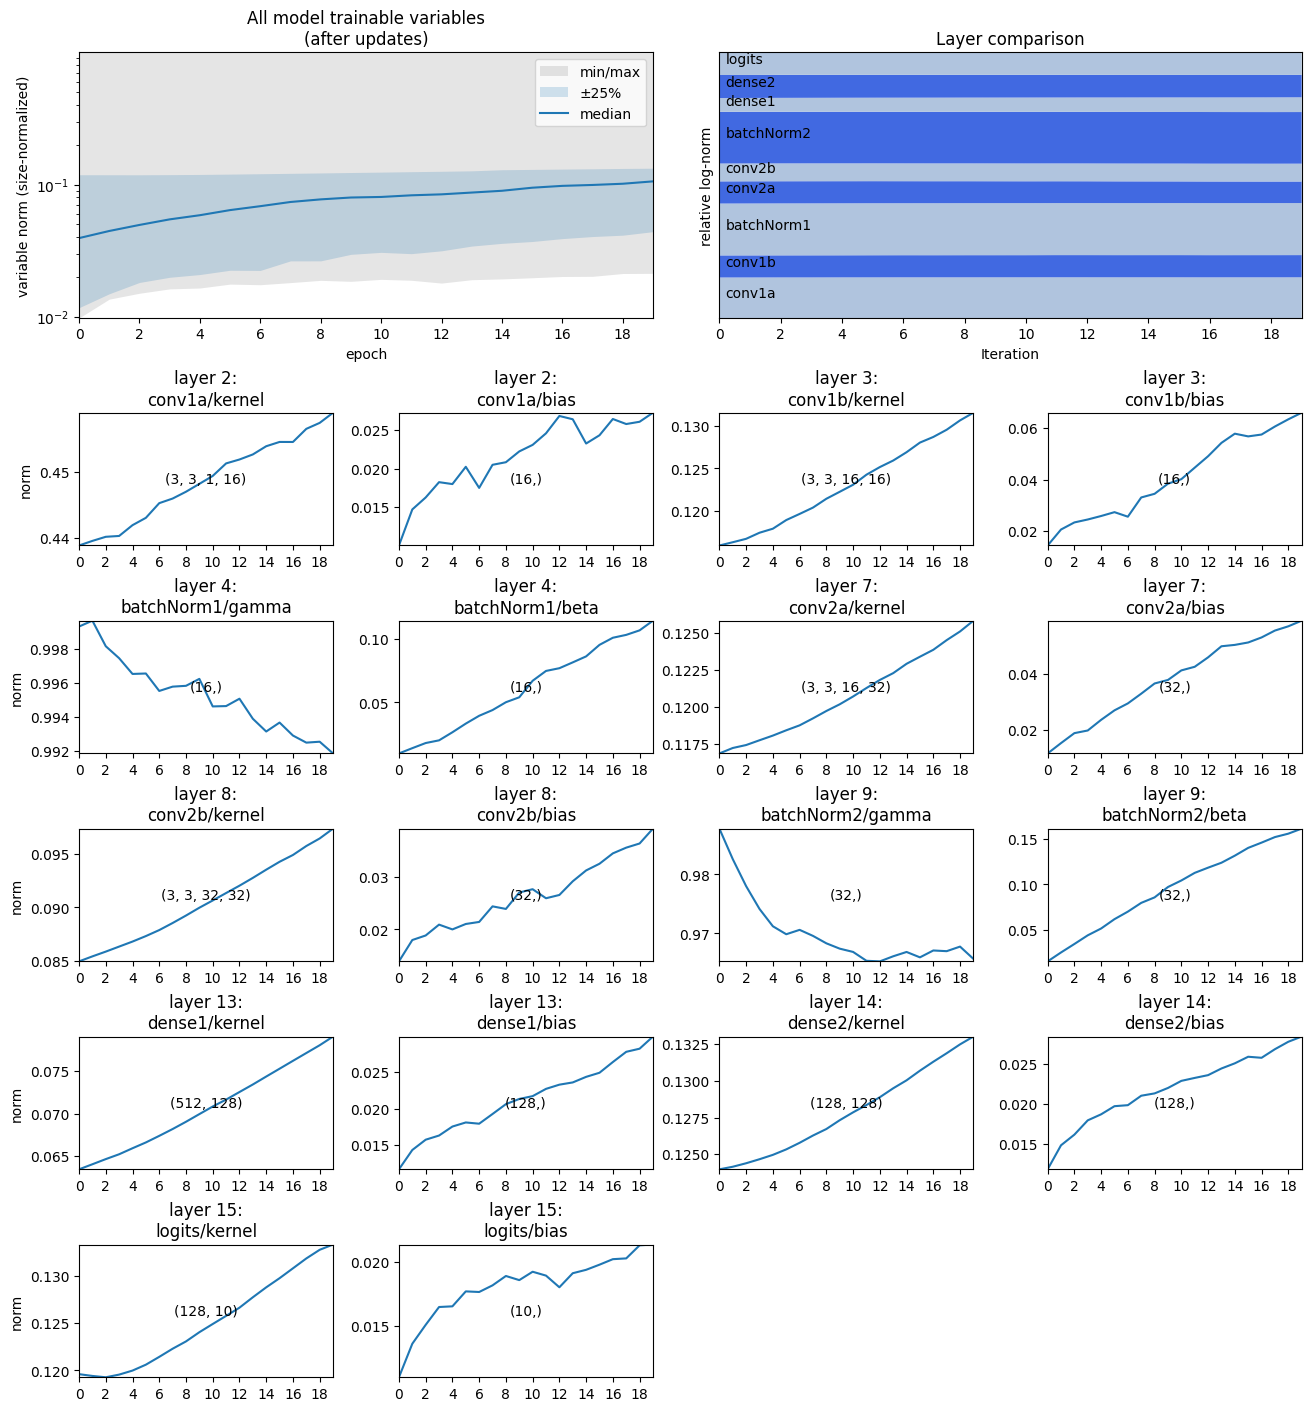

In [ ]:
tinstr.plot_value_history(variables, show='norms', yscale='linear')

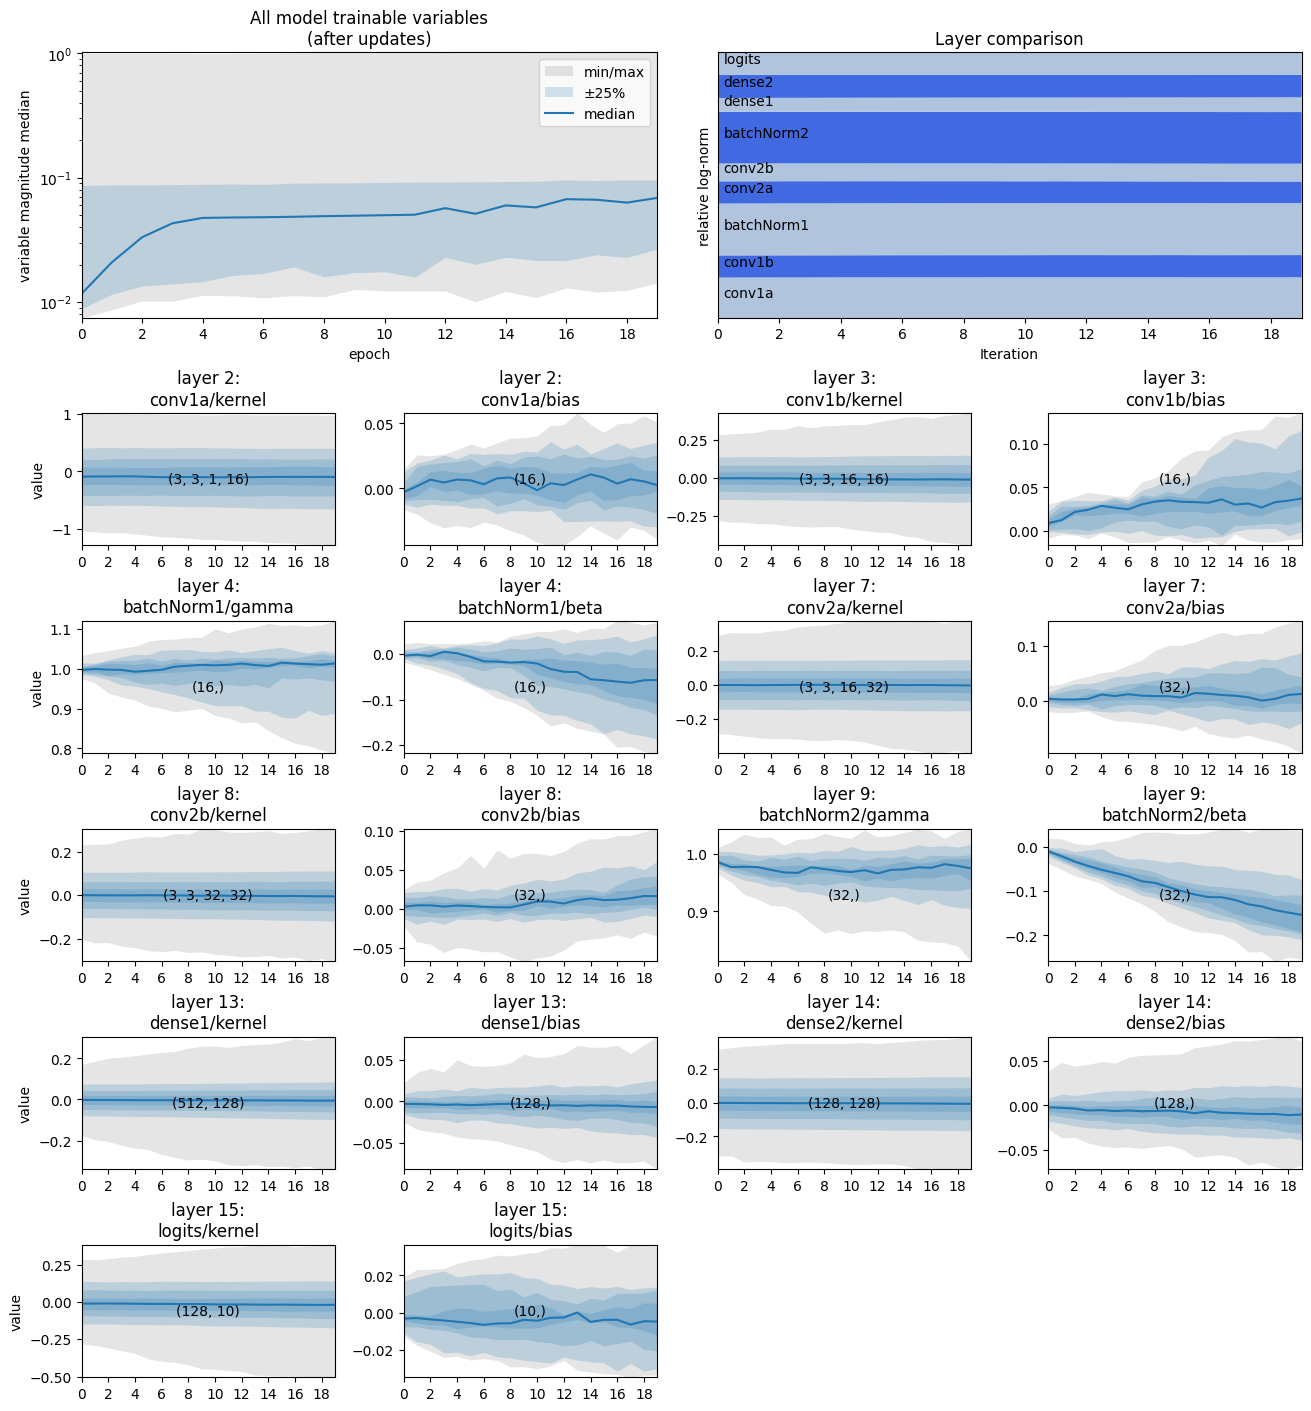

In [ ]:
tinstr.plot_value_history(variables, show='values')

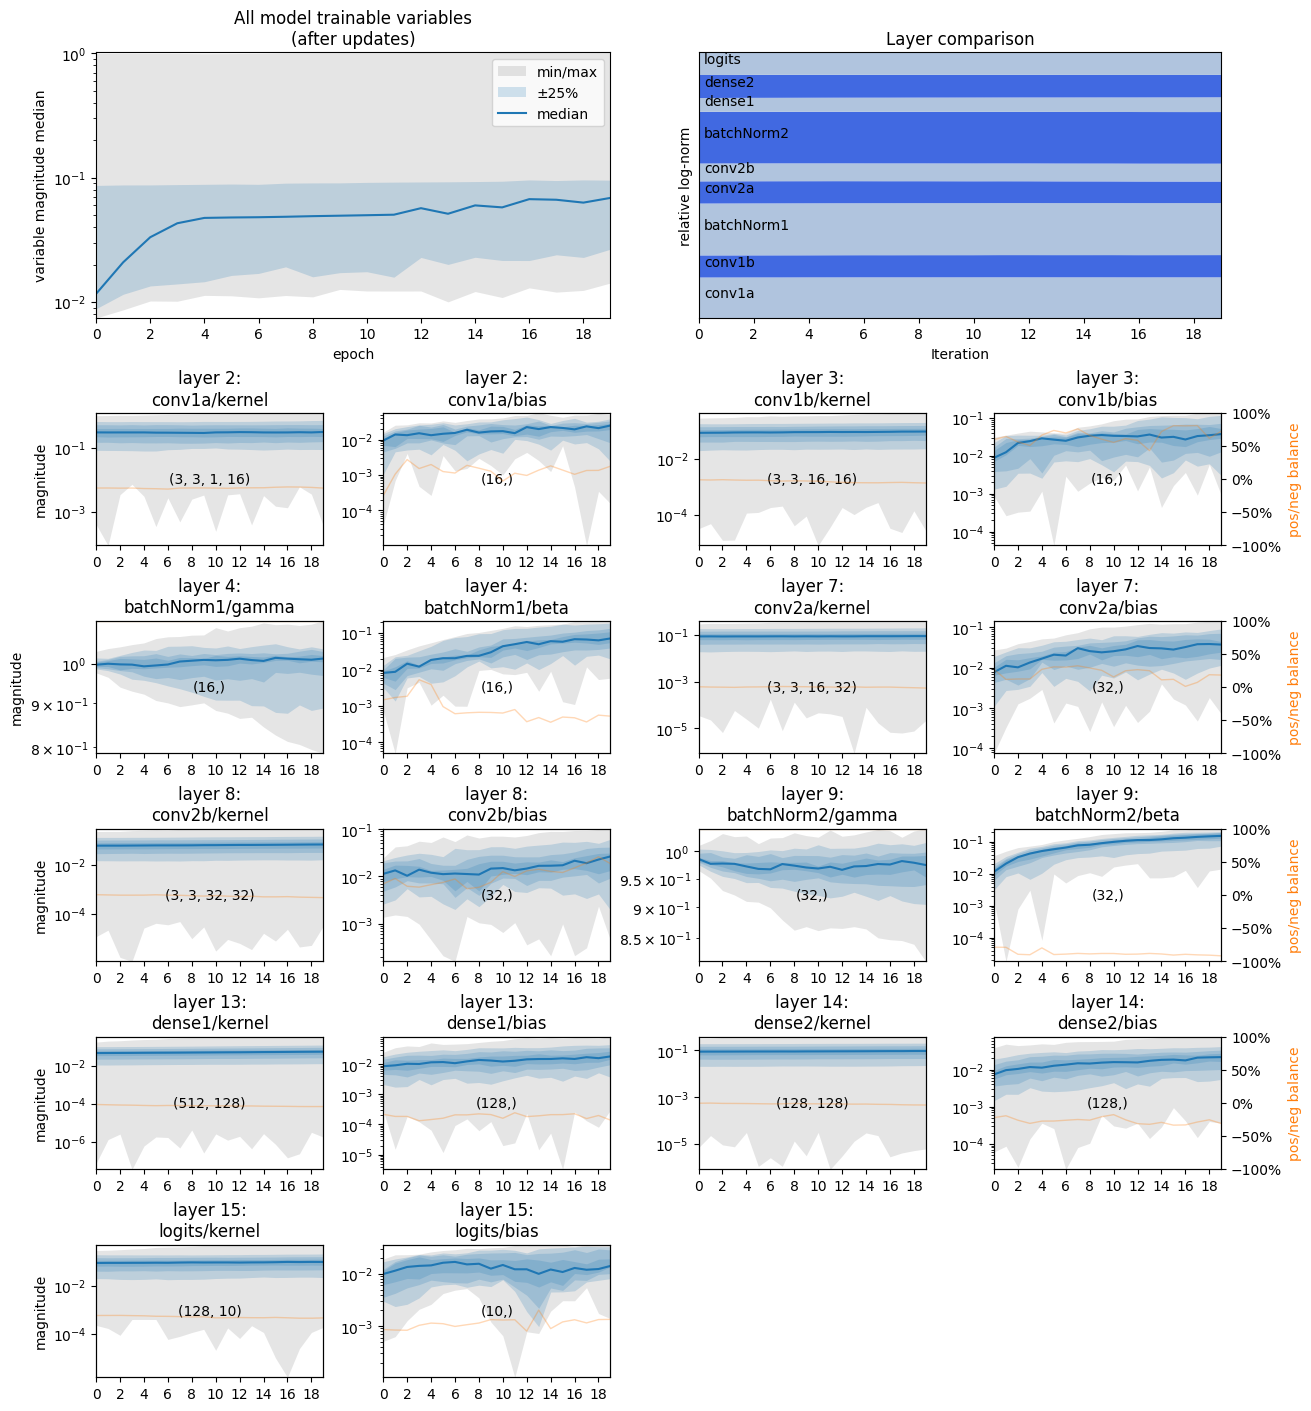

In [ ]:
tinstr.plot_value_history(variables, show='magnitudes')

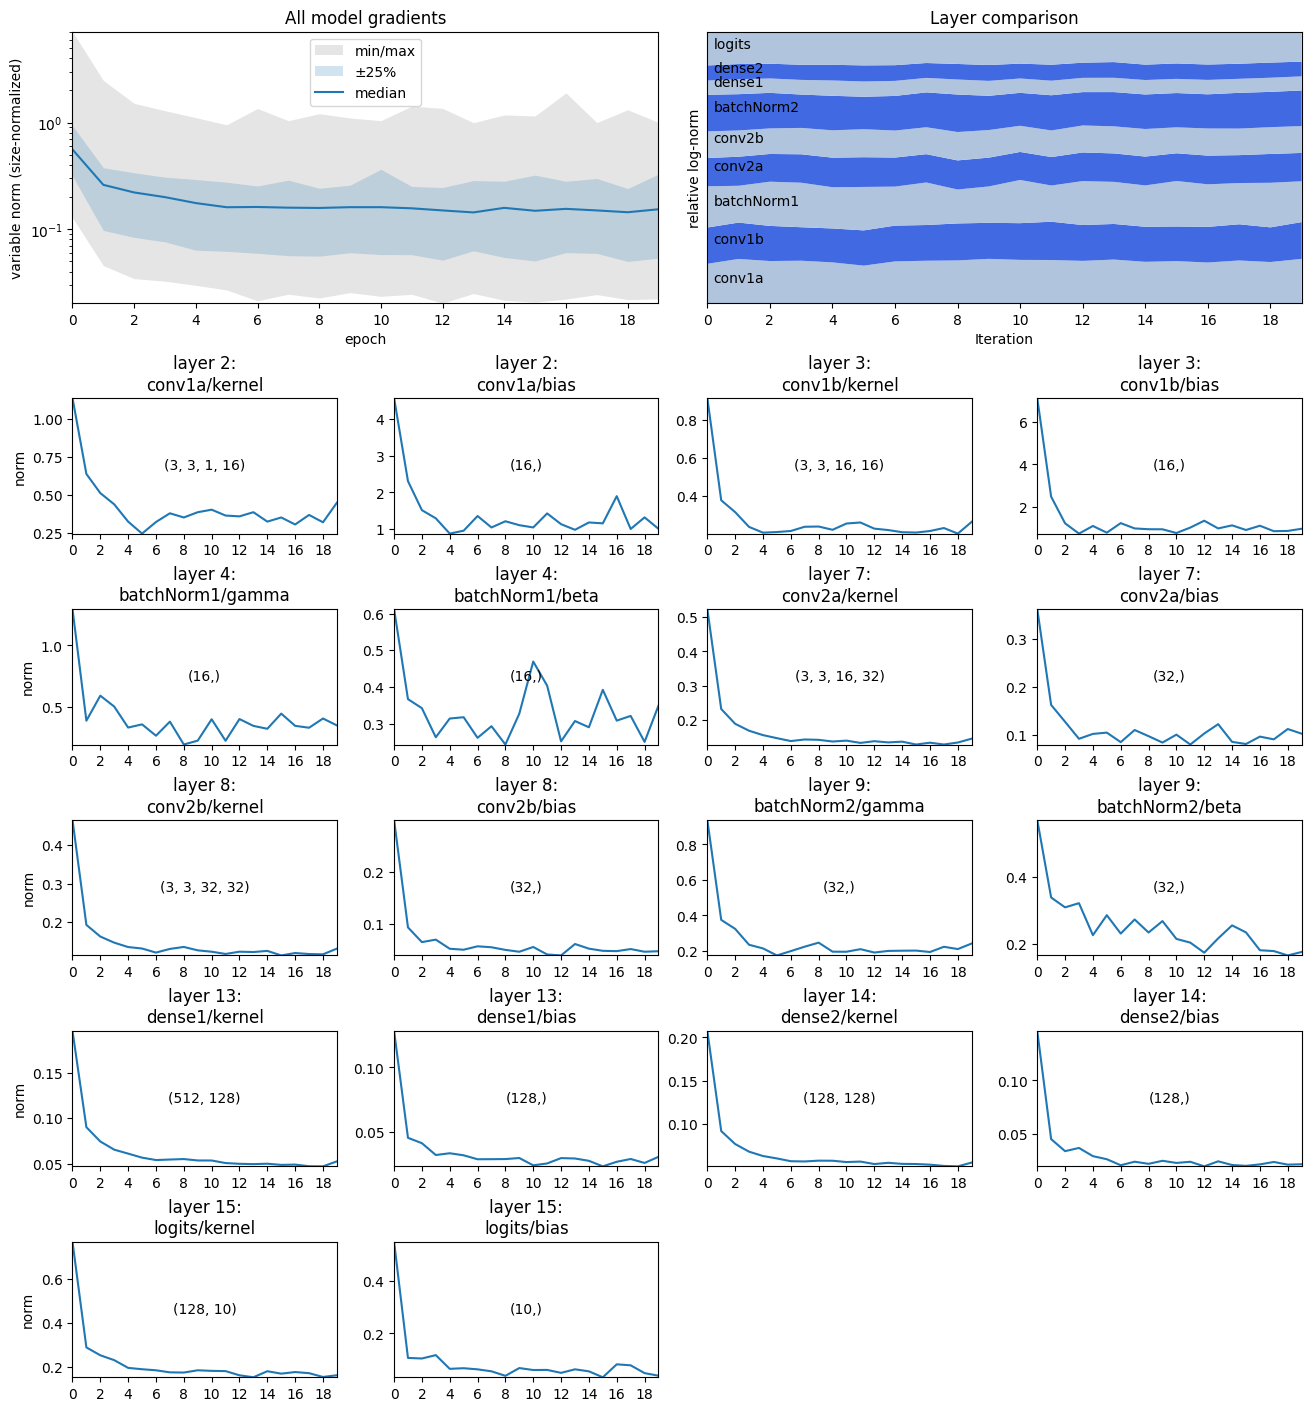

In [ ]:
tinstr.plot_value_history(gradients, show='norms', yscale='linear')

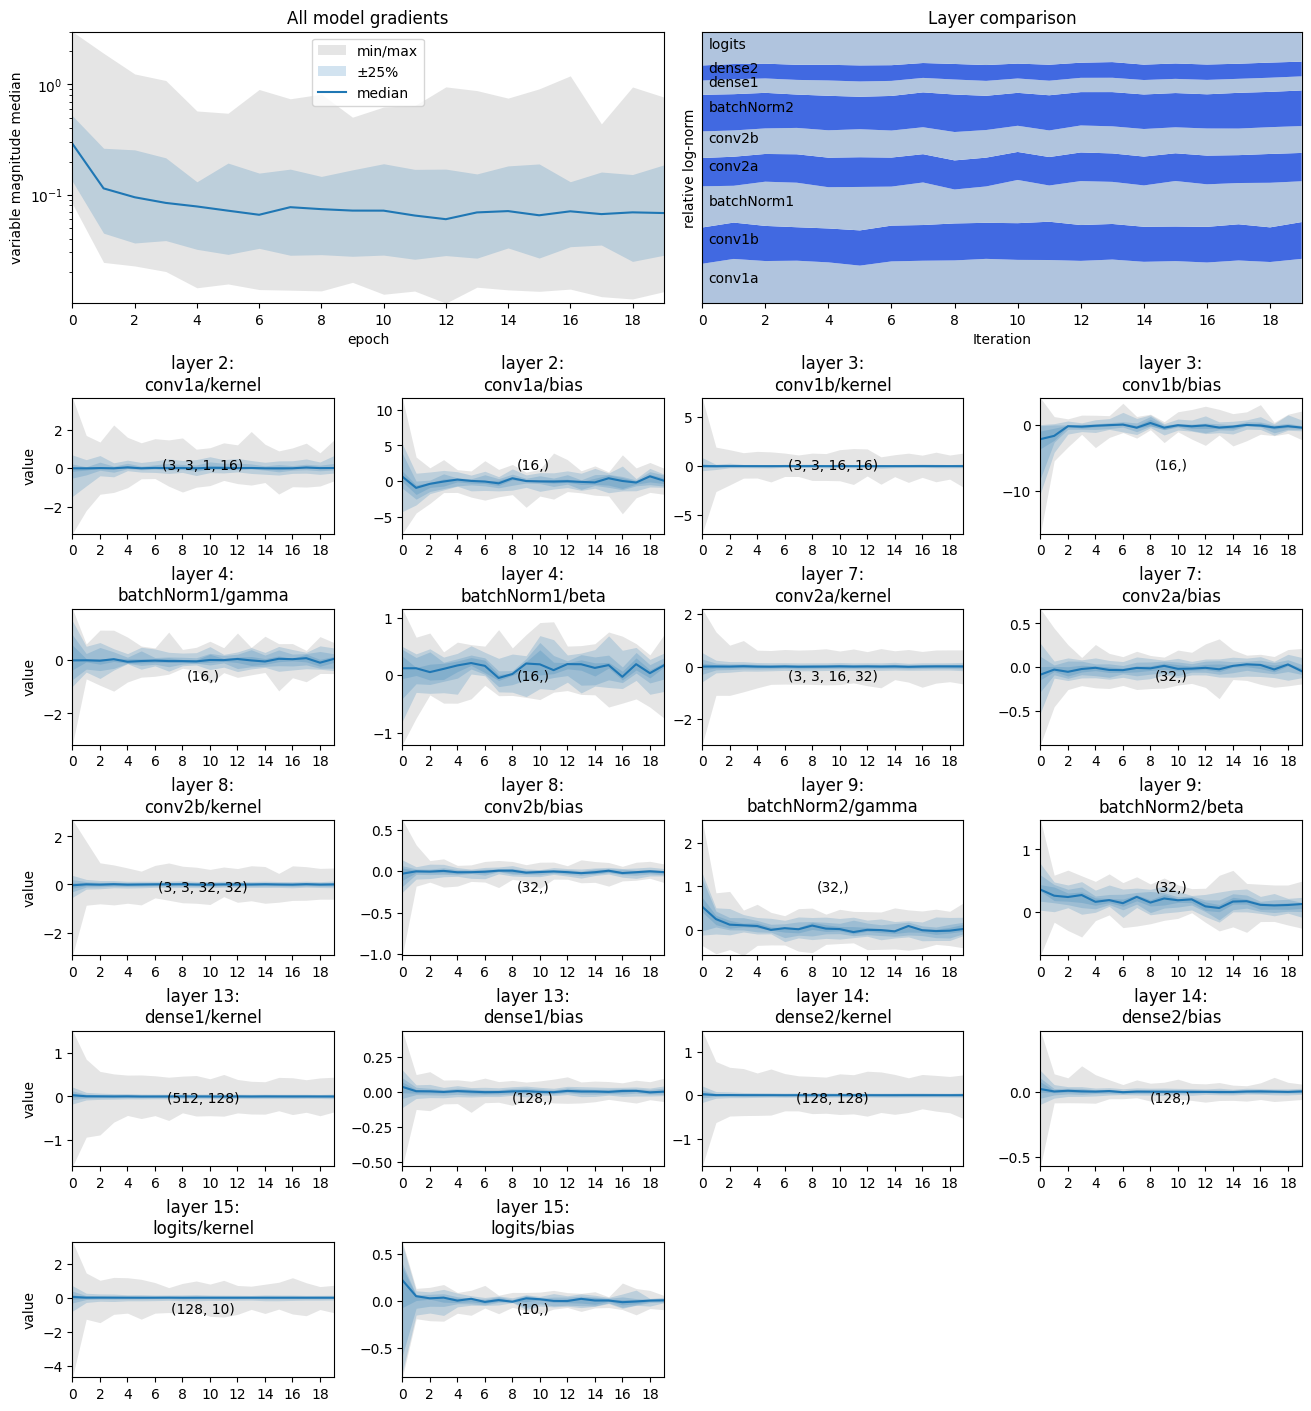

In [ ]:
tinstr.plot_value_history(gradients, show='values')

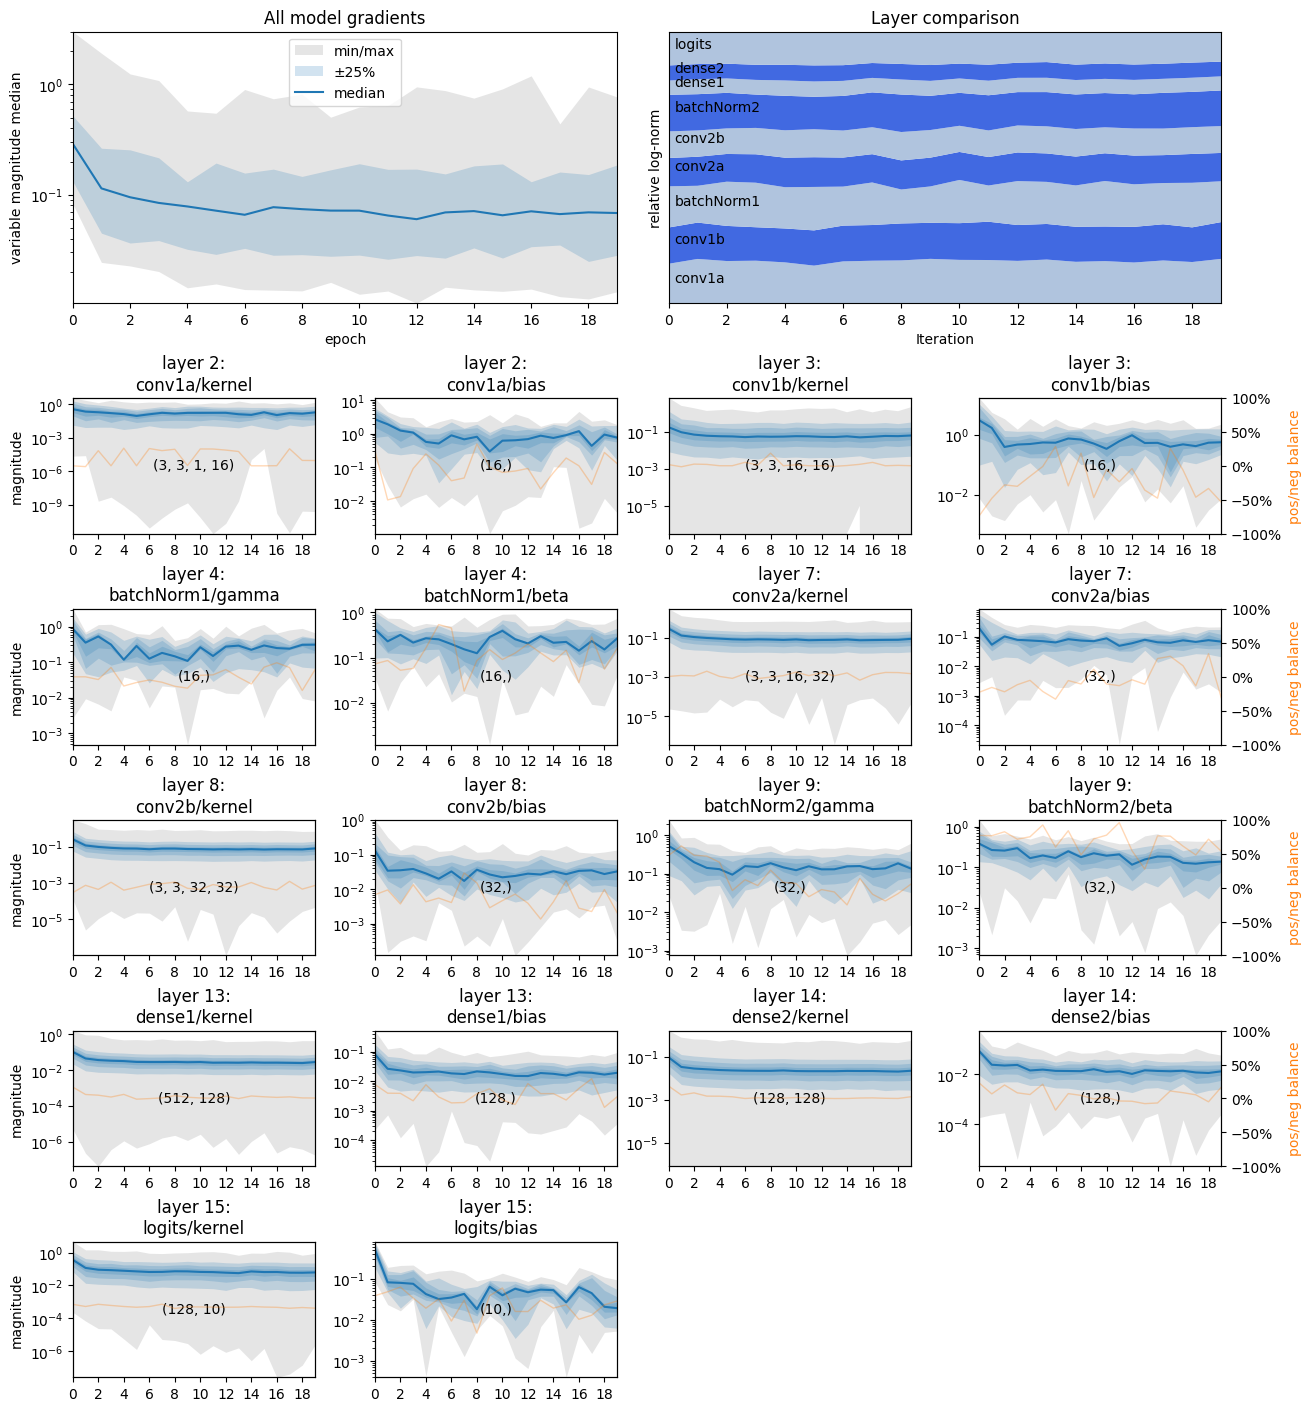

In [ ]:
tinstr.plot_value_history(gradients, show='magnitudes')

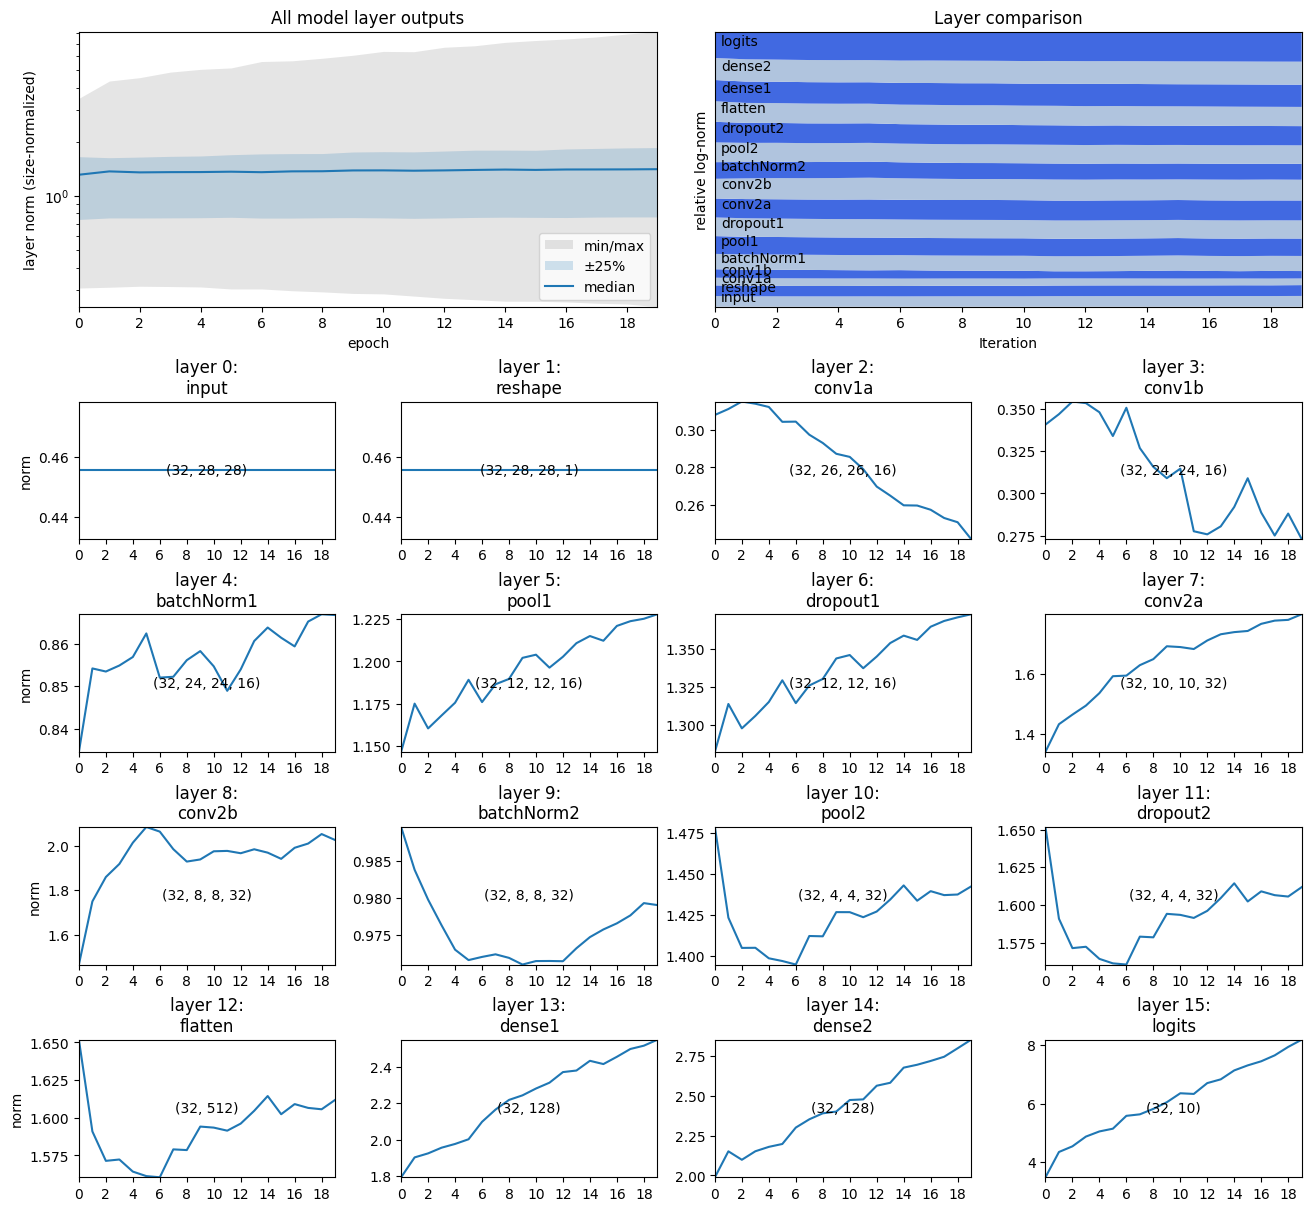

In [ ]:
tinstr.plot_value_history(outputs, show='norms', yscale='linear')

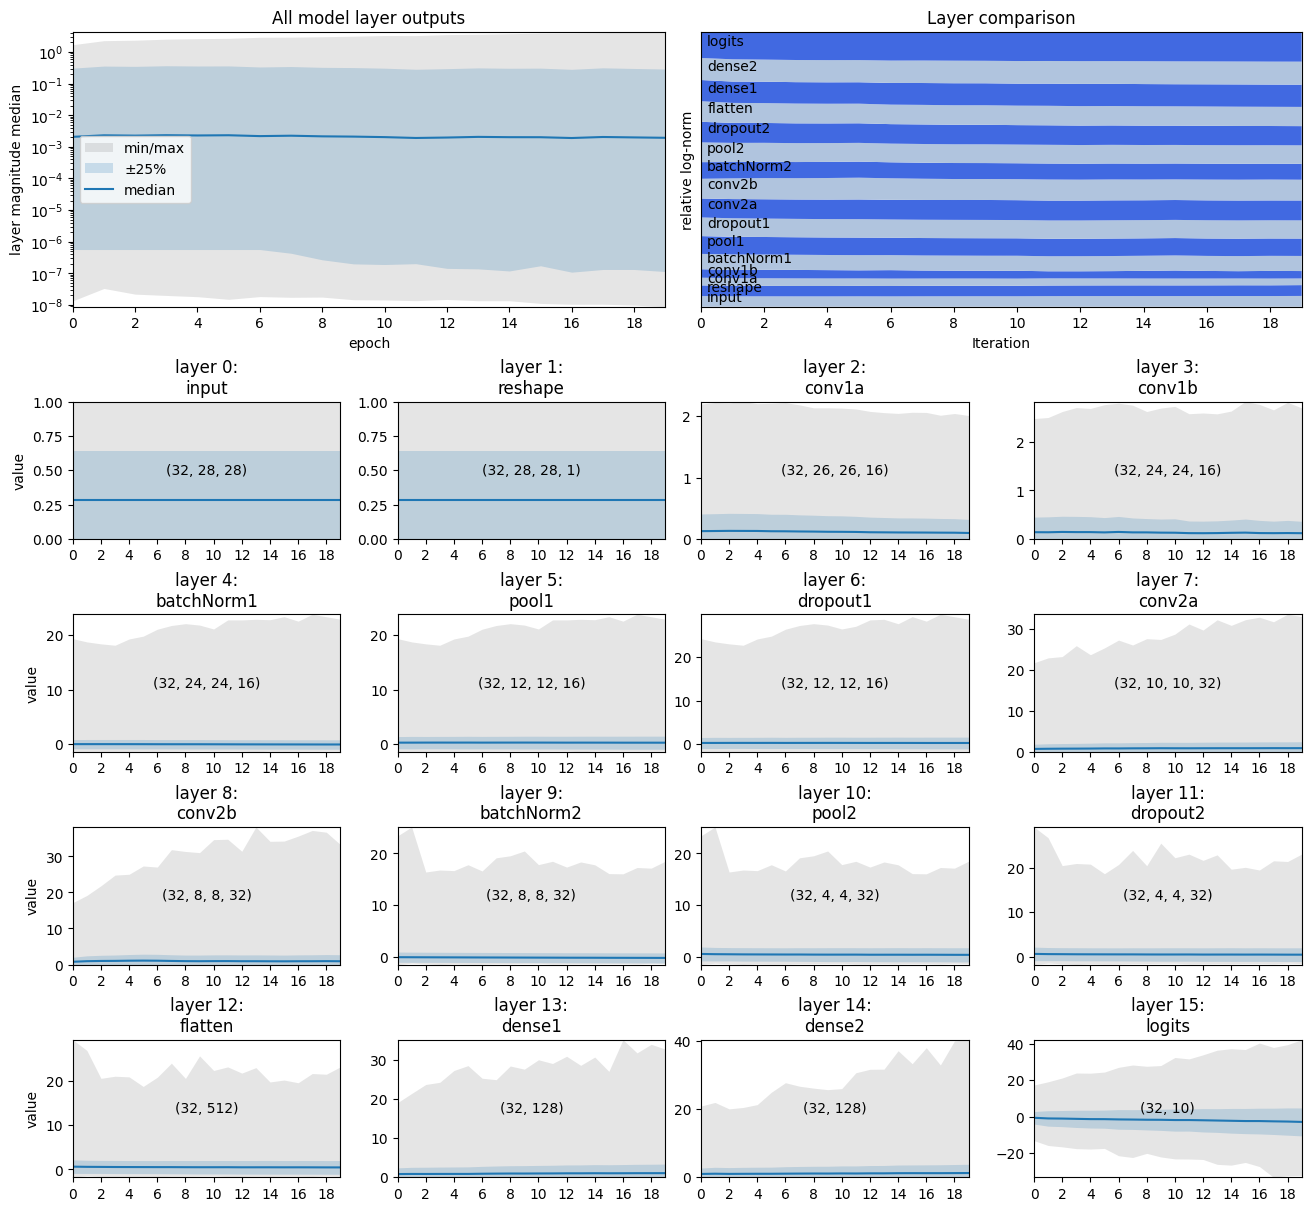

In [ ]:
tinstr.plot_value_history(outputs, show='values')

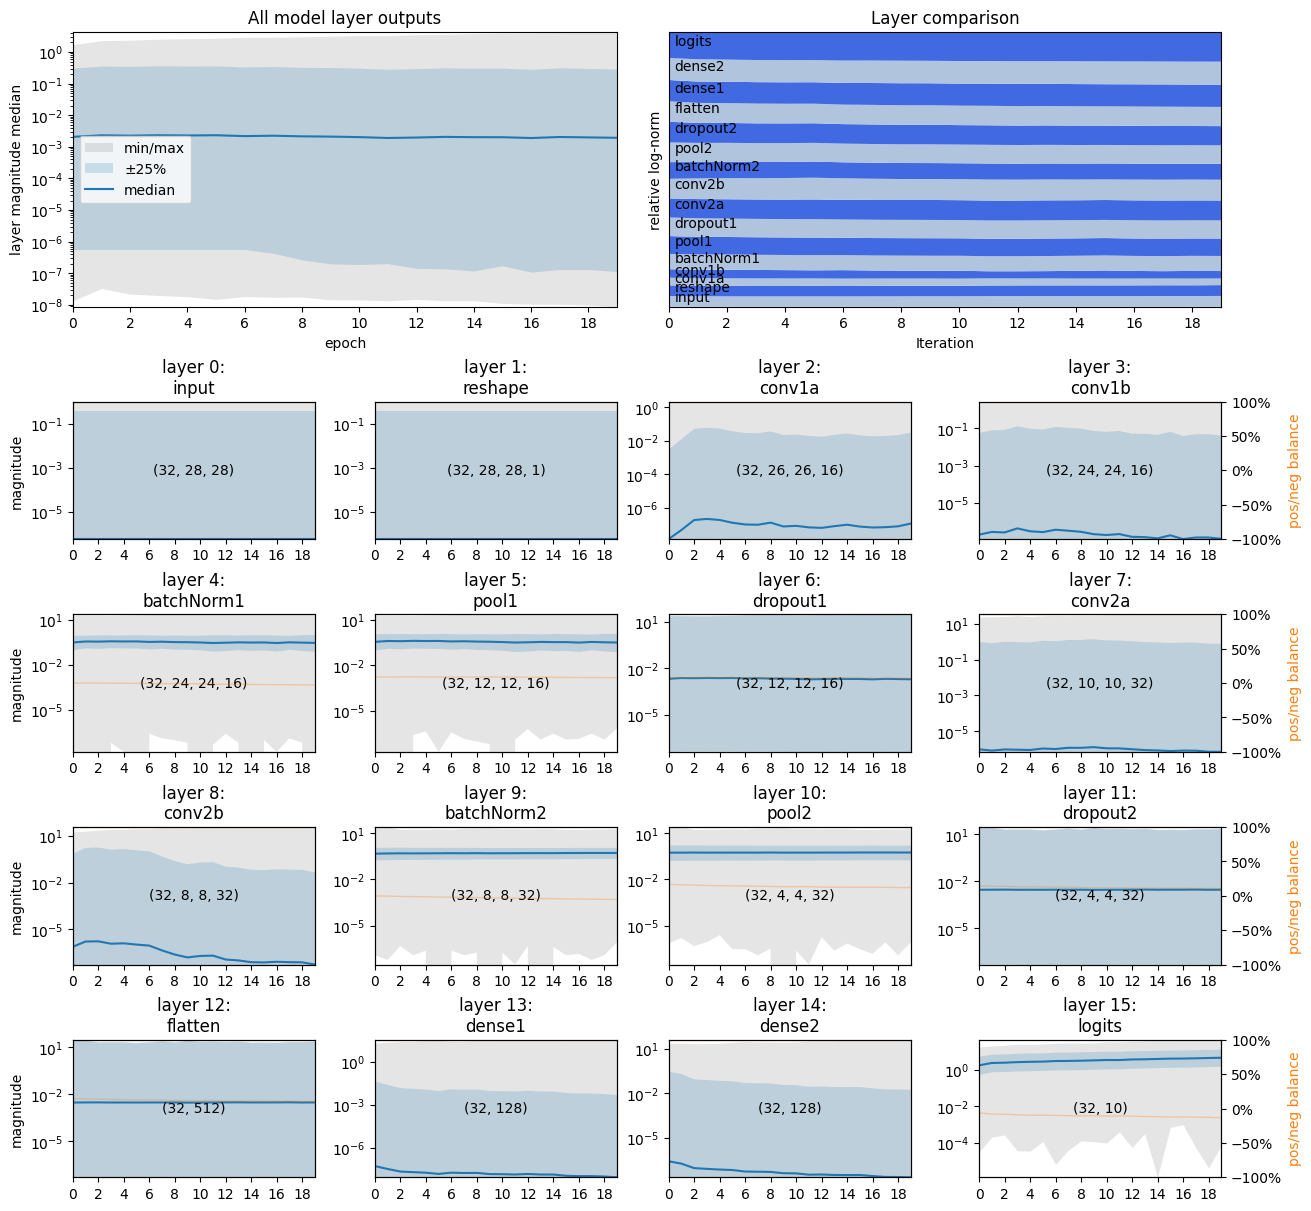

In [ ]:
tinstr.plot_value_history(outputs, show='magnitudes')

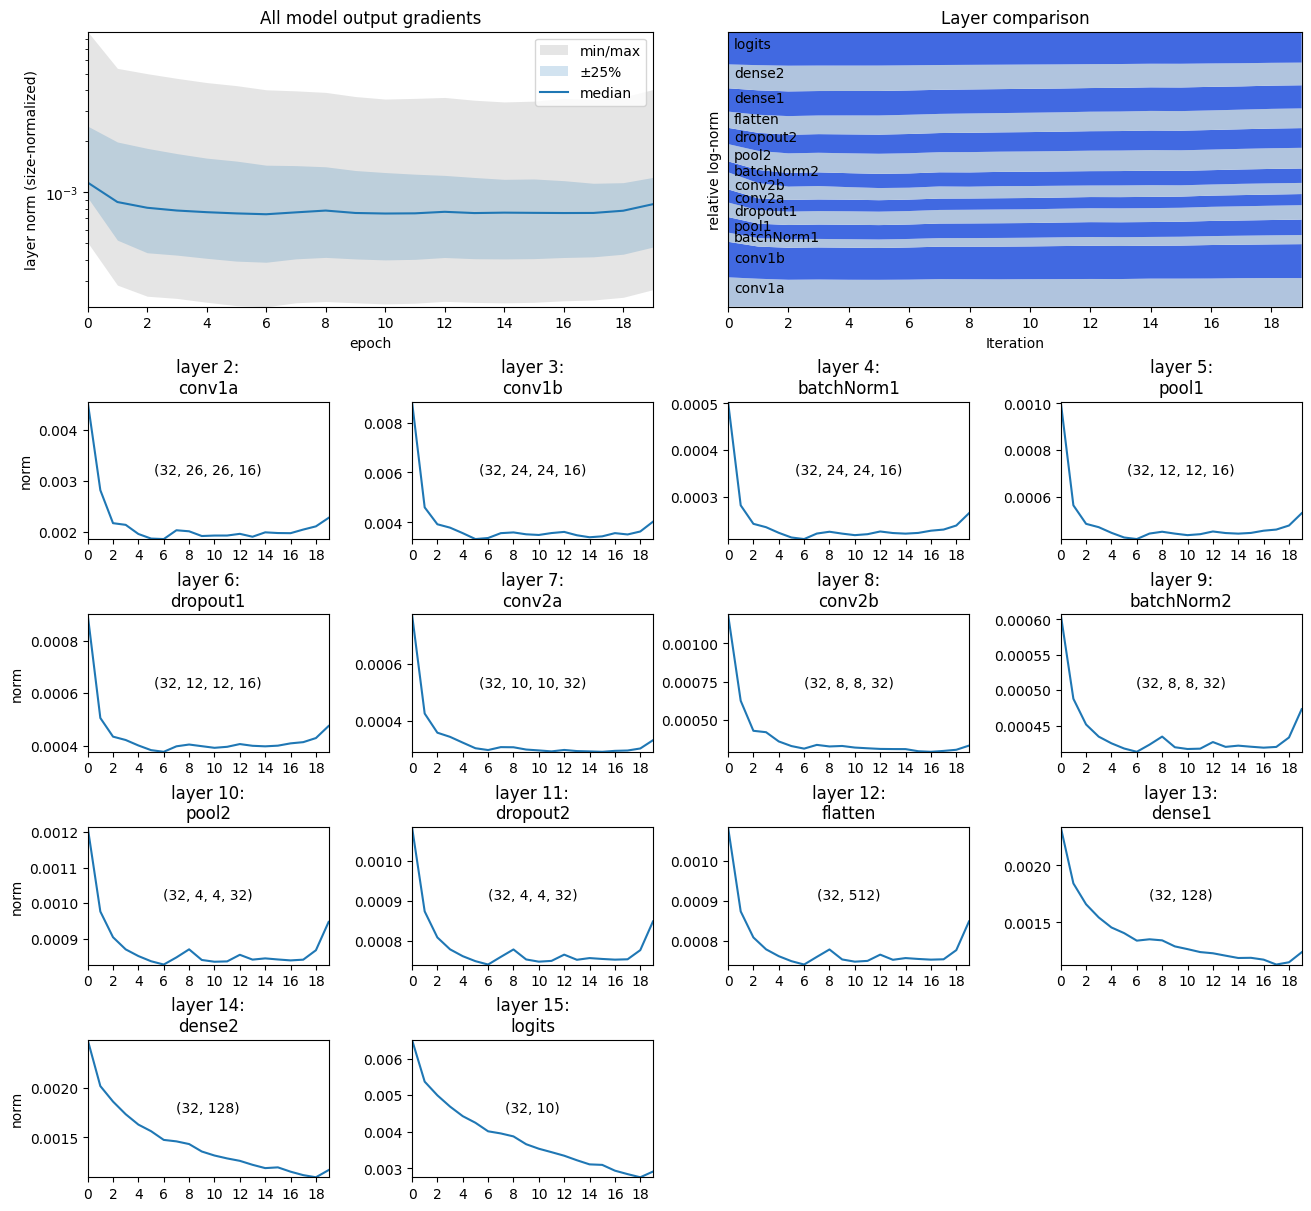

In [ ]:
tinstr.plot_value_history(output_gradients, show='norms', yscale='linear')

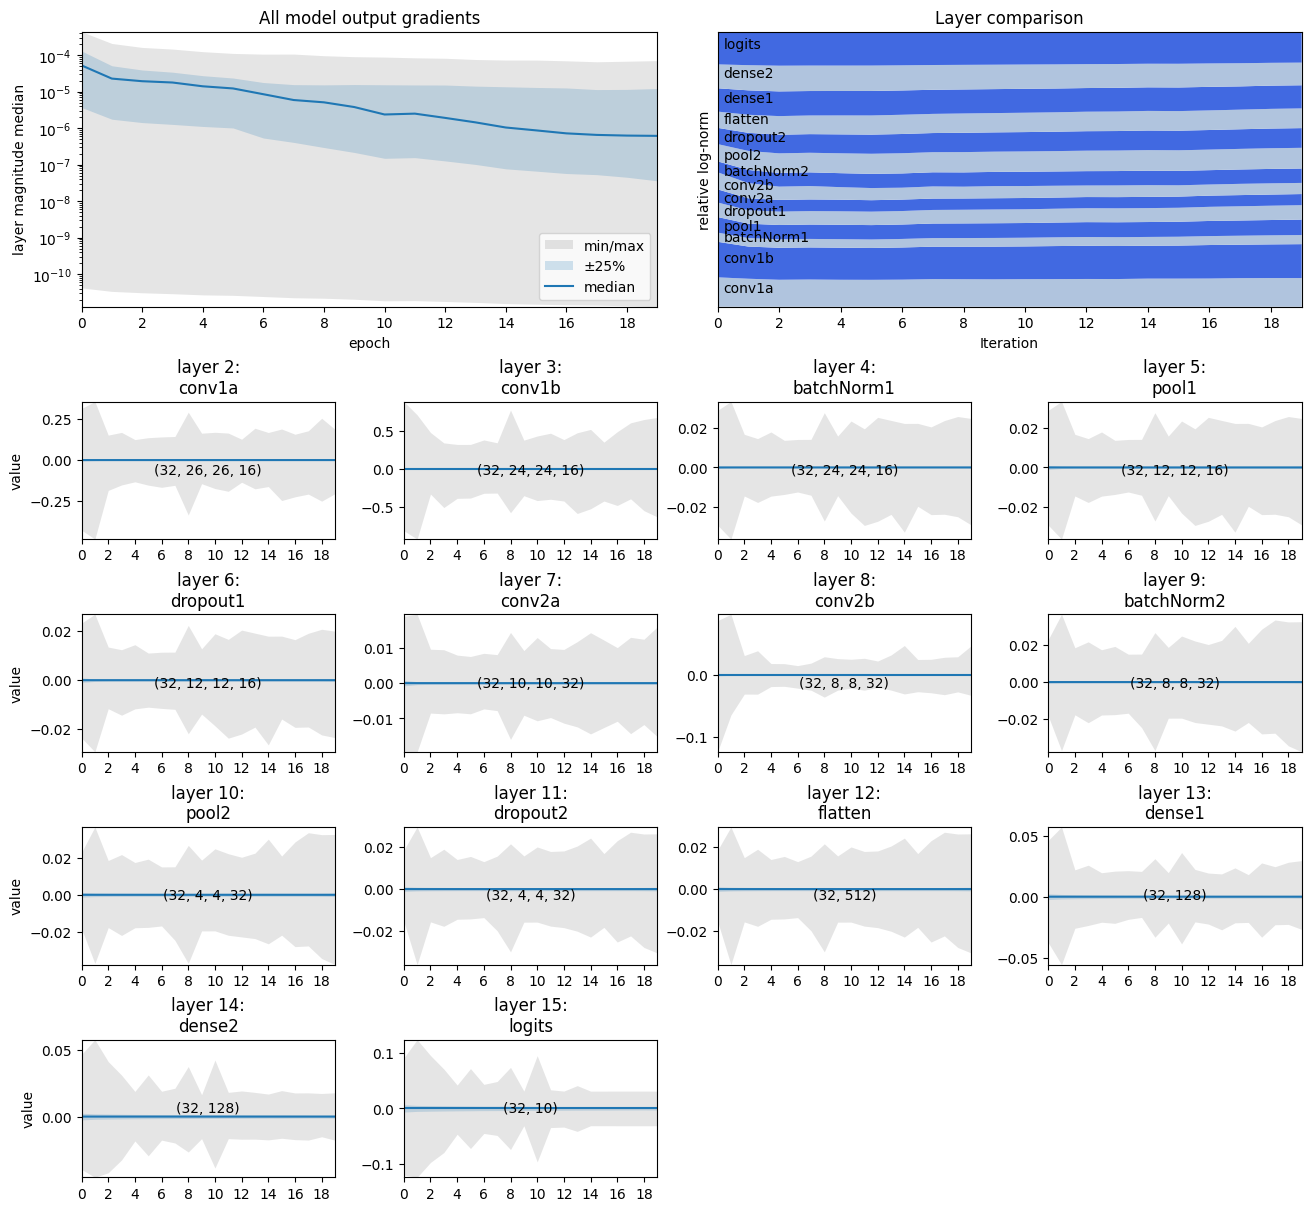

In [ ]:
tinstr.plot_value_history(output_gradients, show='values')

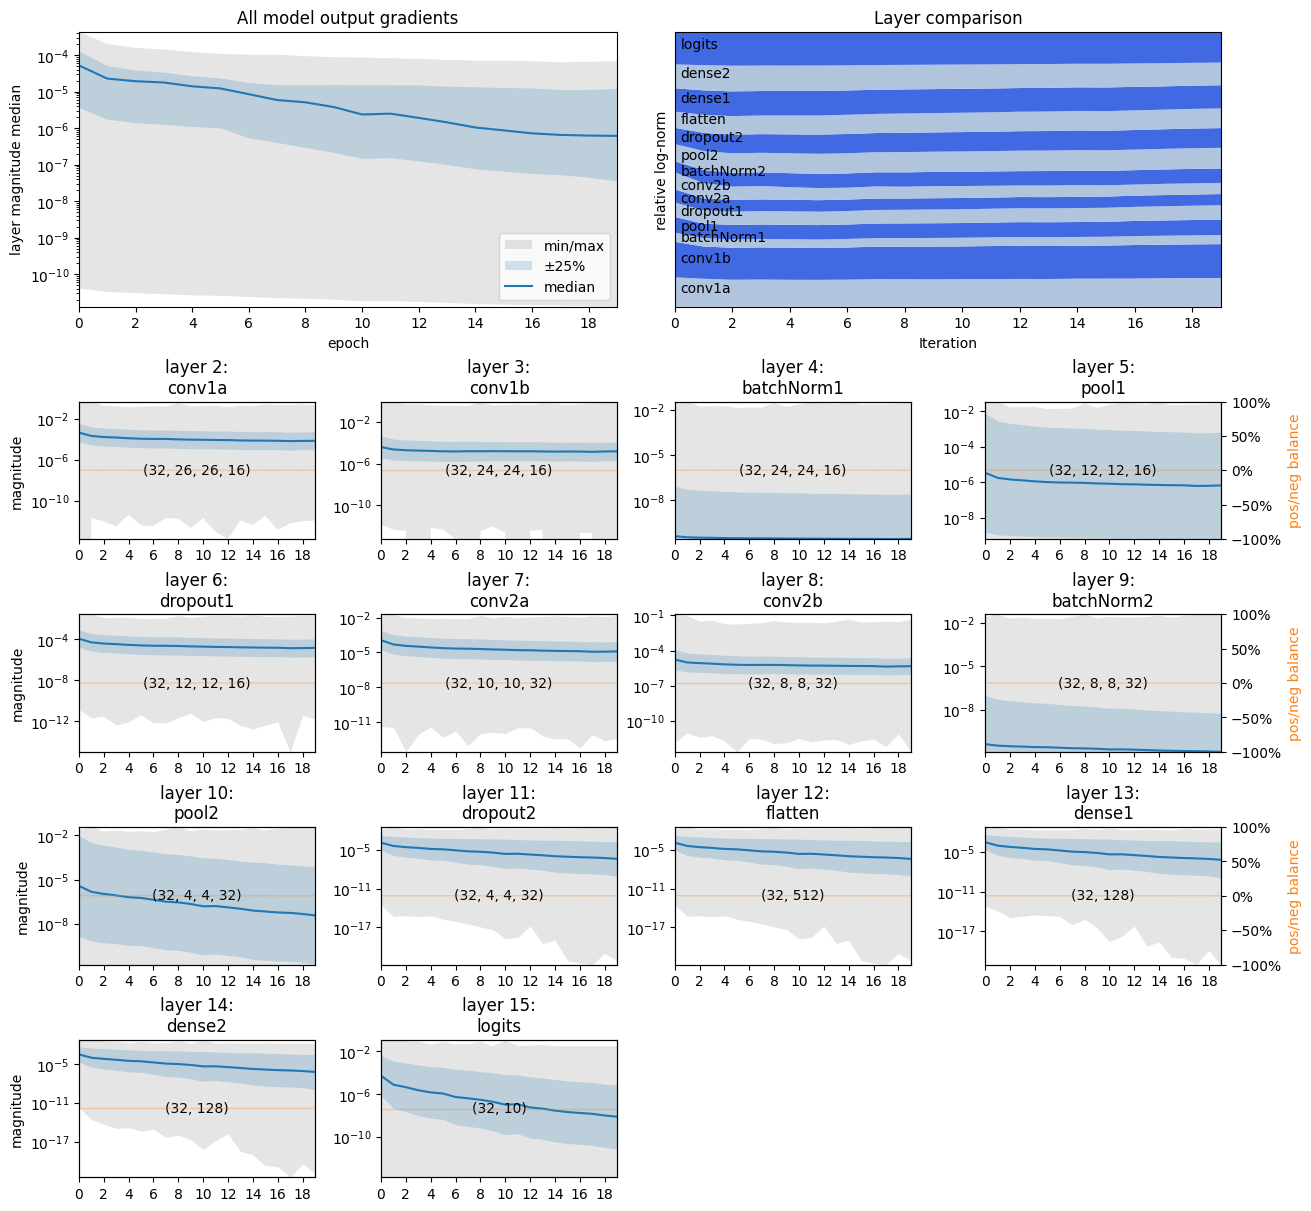

In [ ]:
tinstr.plot_value_history(output_gradients, show='magnitudes')